# **Import**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

from sklearn.linear_model import LinearRegression

# **Data Load**

In [2]:
cd /content/drive/MyDrive/[Projects]/Dacon/제3회 국민대학교 AI빅데이터 분석 경진대회/Data

/content/drive/MyDrive/[Projects]/Dacon/제3회 국민대학교 AI빅데이터 분석 경진대회/Data


In [3]:
train_df = pd.read_csv('./train.csv')
sub_df = pd.read_csv('sample_submission.csv')

In [5]:
train_df

,item_id,year,month,seq,type,hs4,weight,quantity,value
0,DEWLVASR,2022,1,1.0,1,3038,14858.0,0.0,32688.0
1,ELQGMQWE,2022,1,1.0,1,2002,62195.0,0.0,110617.0
2,AHMDUILJ,2022,1,1.0,1,2102,18426.0,0.0,72766.0
3,XIPPENFQ,2022,1,1.0,1,2501,20426.0,0.0,11172.0
4,FTSVTTSR,2022,1,1.0,1,2529,248000.0,0.0,143004.0
...,...,...,...,...,...,...,...,...,...
10831,XIFHSOWQ,2025,7,3.0,1,8708,352.0,0.0,12937.0
10832,FITUEHWN,2025,7,3.0,1,8714,655.0,900.0,16054.0
10833,UGEQLMXM,2025,7,3.0,1,8714,758.0,0.0,74377.0
10834,BLANHGYY,2025,7,3.0,1,9022,345.0,2.0,69720.0


In [6]:
sub_df

,leading_item_id,following_item_id,value
0,DEWLVASR,ELQGMQWE,999999999
1,DEWLVASR,AHMDUILJ,999999999
2,DEWLVASR,XIPPENFQ,999999999
3,DEWLVASR,FTSVTTSR,999999999
4,DEWLVASR,XMKRPGLB,999999999
...,...,...,...
9895,RJCAXSGH,RUVXNNVA,999999999
9896,RJCAXSGH,TANNMIMB,999999999
9897,RJCAXSGH,GIKPEWTY,999999999
9898,RJCAXSGH,PLMZALFA,999999999


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10836 entries, 0 to 10835
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   item_id   10836 non-null  object 
 1   year      10836 non-null  int64  
 2   month     10836 non-null  int64  
 3   seq       10836 non-null  float64
 4   type      10836 non-null  int64  
 5   hs4       10836 non-null  int64  
 6   weight    10836 non-null  float64
 7   quantity  10836 non-null  float64
 8   value     10836 non-null  float64
dtypes: float64(4), int64(4), object(1)
memory usage: 762.0+ KB


# **EDA**

## **결측치, 이상치**

In [18]:
train_df.isna().sum()

,0
item_id,0
year,0
month,0
seq,0
type,0
hs4,0
weight,0
quantity,0
value,0


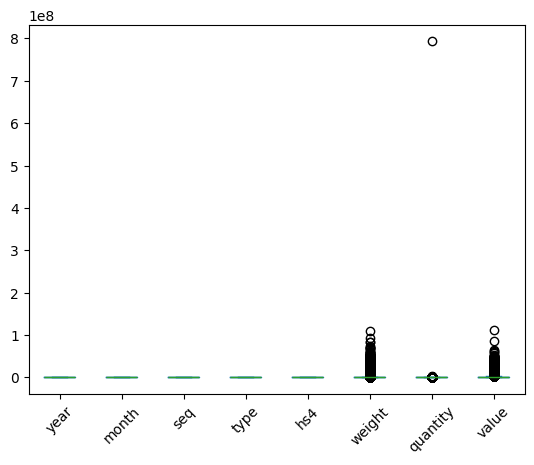

In [14]:
train_df.plot(kind='box')
plt.xticks(rotation=45)
plt.show()

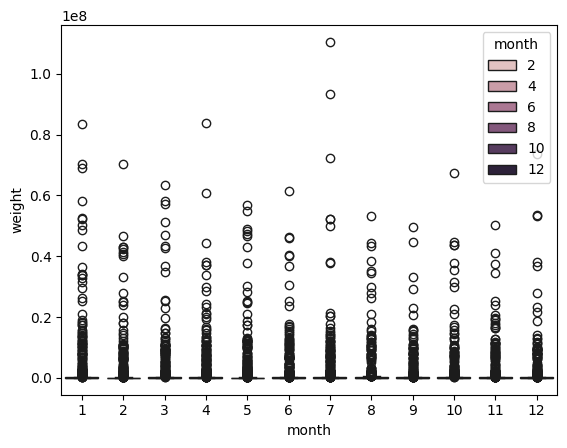

In [15]:
sns.boxplot(data=train_df,
            x='month',
            y='weight',
            hue='month')
plt.show()

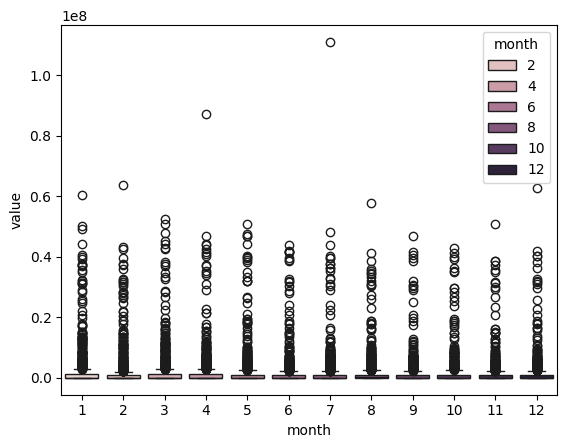

In [16]:
sns.boxplot(data=train_df,
            x='month',
            y='value',
            hue='month')
plt.show()

## **변수분포**

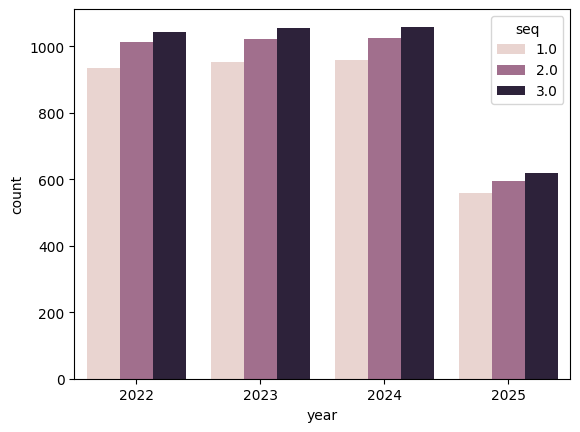

In [19]:
sns.countplot(data=train_df,
              x='year',
              hue='seq')
plt.show()

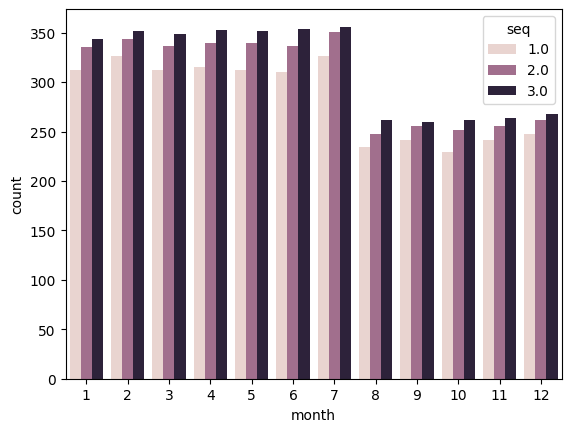

In [20]:
sns.countplot(data=train_df,
              x='month',
              hue='seq')
plt.show()

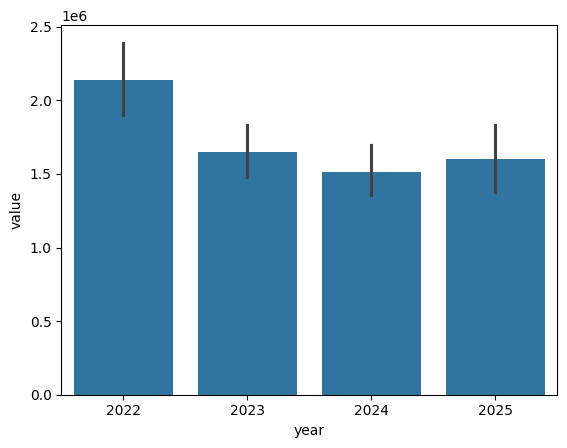

In [21]:
sns.barplot(data=train_df,
            x='year',
            y='value')
plt.show()

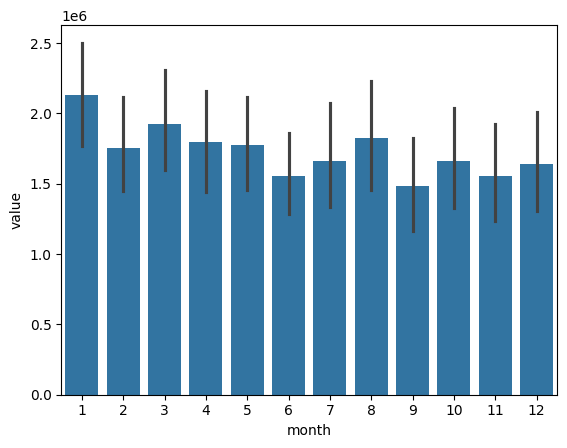

In [22]:
sns.barplot(data=train_df,
            x='month',
            y='value')
plt.show()

## **변수간 관계**

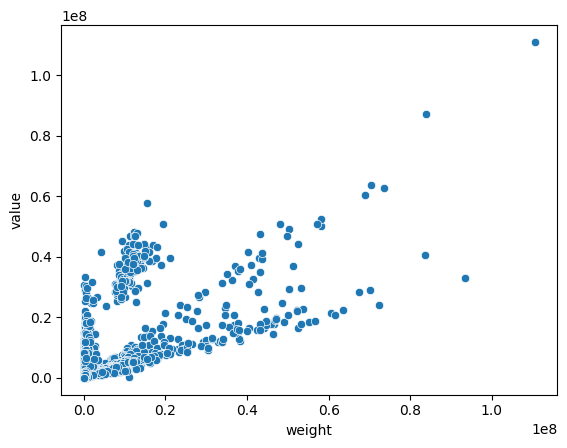

In [23]:
sns.scatterplot(train_df,
                x='weight',
                y='value')
plt.show()

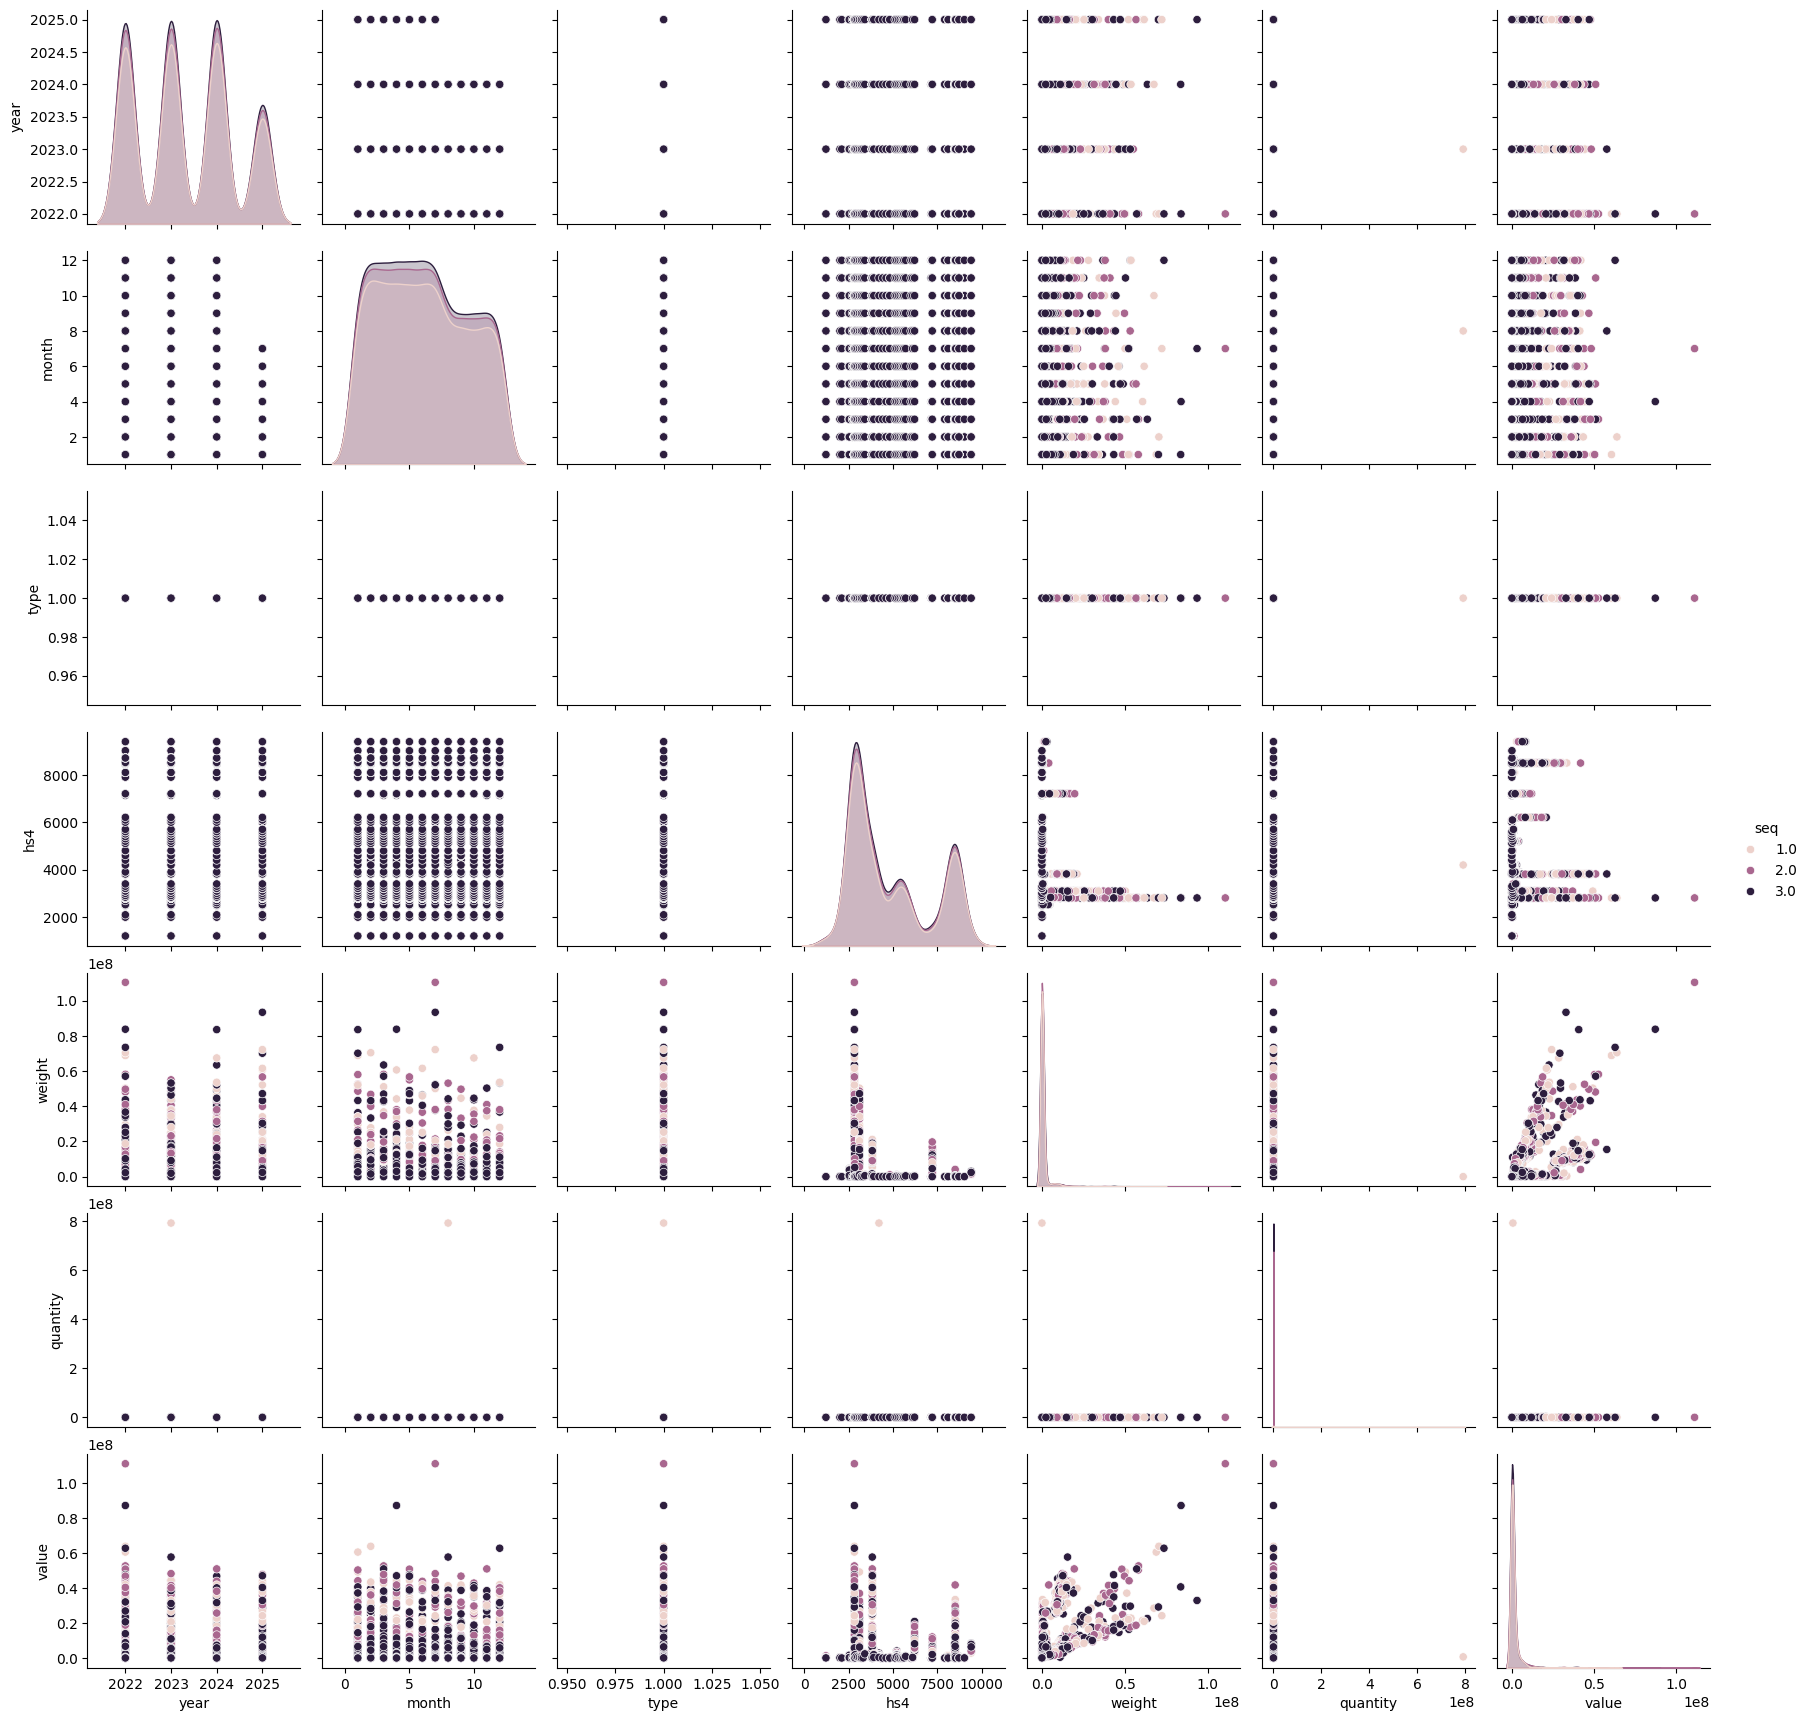

In [24]:
sns.pairplot(train_df,
             hue='seq')
plt.show()

## **Feature Engineering**

In [25]:
display(train_df.apply(lambda x: len(np.unique(x)), axis=0))
display(train_df.apply(lambda x: np.unique(x), axis=0))

,0
item_id,100
year,4
month,12
seq,3
type,1
hs4,71
weight,7438
quantity,1226
value,9686


,0
item_id,"[AANGBULD, AHMDUILJ, ANWUJOKX, APQGTRMF, ATLDM..."
year,"[2022, 2023, 2024, 2025]"
month,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]"
seq,"[1.0, 2.0, 3.0]"
type,[1]
hs4,"[1210, 2002, 2102, 2501, 2529, 2612, 2701, 271..."
weight,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
quantity,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."
value,"[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, ..."


In [26]:
train_df['hs4'].value_counts()

,count
hs4,
2805,646
3824,535
2811,516
8501,423
8505,387
...,...
4302,9
7142,8
2612,6


In [30]:
train_df.groupby(['item_id', 'year', 'month'], as_index=False)['value'].size().sort_values(by='size', ascending=False)

,item_id,year,month,size
3759,ZXERAXWP,2024,3,3
3758,ZXERAXWP,2024,2,3
3757,ZXERAXWP,2024,1,3
3756,ZXERAXWP,2023,12,3
3755,ZXERAXWP,2023,11,3
...,...,...,...,...
294,BLANHGYY,2022,2,1
303,BLANHGYY,2023,3,1
101,APQGTRMF,2023,10,1
106,APQGTRMF,2024,3,1


In [31]:
train_df[(train_df['item_id'] == 'ZXERAXWP') &  (train_df['year'] == 2024) & (train_df['month'] == 3)]

,item_id,year,month,seq,type,hs4,weight,quantity,value
6572,ZXERAXWP,2024,3,1.0,1,4802,281.0,0.0,5579.0
6654,ZXERAXWP,2024,3,2.0,1,4802,11.0,0.0,742.0
6739,ZXERAXWP,2024,3,3.0,1,4802,17.0,0.0,1179.0


In [39]:
train_df.groupby(["hs4"], as_index=False)["item_id"].apply(lambda x: len(np.unique(x))).sort_values(by='item_id', ascending=False).reset_index(drop=True)

,hs4,item_id
0,2805,6
1,3824,5
2,8501,5
3,2811,4
4,8102,3
...,...,...
66,8479,1
67,8527,1
68,8708,1
69,9022,1


In [40]:
train_df.groupby(["hs4"], as_index=False)["item_id"].apply(lambda x: np.unique(x))

,hs4,item_id
0,1210,[JBVHSUWY]
1,2002,[ELQGMQWE]
2,2102,[AHMDUILJ]
3,2501,[XIPPENFQ]
4,2529,"[FTSVTTSR, XMKRPGLB]"
...,...,...
66,8527,[VMAQSTJE]
67,8708,[XIFHSOWQ]
68,8714,"[FITUEHWN, UGEQLMXM]"
69,9022,[BLANHGYY]


In [41]:
tmp_df = train_df.groupby(["hs4"], as_index=False)["item_id"].apply(lambda x: np.unique(x))
tmp_df['item_id_len'] = train_df.groupby(["hs4"], as_index=False)["item_id"].apply(lambda x: len(np.unique(x)))['item_id']
hs4_tmp_df = tmp_df.sort_values(by='item_id_len', ascending=False).reset_index(drop=True)

display(hs4_tmp_df.head(20))

,hs4,item_id,item_id_len
0,2805,"[BSRMSVTC, DJBLNPNC, RCBZUSIM, SUOYXCHP, WQMVC...",6
1,3824,"[FCYBOAXC, IGDVVKUD, LPHPPJUG, PYZMVUWD, SNHYO...",5
2,8501,"[GKQIJYDH, KFQSHBNH, QKXNTIIB, RJCAXSGH, UQYUI...",5
3,2811,"[DNMPSKTB, RJGPVEXX, VWMBASNE, WPQXWHYO]",4
4,8102,"[FQCLOEXA, KEUWZRKO, UIFPPCLR]",3
5,8505,"[GYHKIVQT, ROACSLMG, VBYCLTYZ]",3
6,3815,"[OJIFIHMZ, STZDBITS, XIIEJNEE]",3
7,2807,"[DDEXPPXU, LLHREMKS, YSYHGLQK]",3
8,7207,"[SDWAYPIK, TGOELCAG]",2
9,2846,"[FRHNWLNI, MBSBZBXA]",2


In [51]:
dct_hs4_tmp_df  = hs4_tmp_df[['hs4', 'item_id']].set_index('hs4').to_dict()['item_id']
list(dct_hs4_tmp_df[2805]) # hs4 코드  = 2805 의 경우에 포함된 상품들

['BSRMSVTC', 'DJBLNPNC', 'RCBZUSIM', 'SUOYXCHP', 'WQMVCOEM', 'ZKENOUDA']

### monthly data 탐색

In [42]:
# year, month, item_id 기준으로 value 합산 (seq만 다르다면 value 합산)
monthly = (
    train_df
    .groupby(["item_id", "year", "month"], as_index=False)["value"]
    .sum()
)

# year, month를 하나의 키(ym)로 묶기
monthly["ym"] = pd.to_datetime(
    monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2) # 'ym' as 'datetime64[ns]'
)

monthly.head()

,item_id,year,month,value,ym
0,AANGBULD,2022,1,14276.0,2022-01-01
1,AANGBULD,2022,2,52347.0,2022-02-01
2,AANGBULD,2022,3,53549.0,2022-03-01
3,AANGBULD,2022,5,26997.0,2022-05-01
4,AANGBULD,2022,6,84489.0,2022-06-01


In [45]:
pivot = (
    monthly
    .pivot(index="item_id", columns="ym", values="value")
    .fillna(0.0)
)

pivot.head()

ym,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,...,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01
item_id,,,,,,,,,,,,,,,,,,,,,
AANGBULD,14276.0,52347.0,53549.0,0.0,26997.0,84489.0,0.0,0.0,0.0,0.0,...,428725.0,144248.0,26507.0,25691.0,25805.0,0.0,38441.0,0.0,441275.0,533478.0
AHMDUILJ,242705.0,120847.0,197317.0,126142.0,71730.0,149138.0,186617.0,169995.0,140547.0,89292.0,...,123085.0,143451.0,78649.0,125098.0,80404.0,157401.0,115509.0,127473.0,89479.0,101317.0
ANWUJOKX,0.0,0.0,0.0,63580.0,81670.0,26424.0,8470.0,0.0,0.0,80475.0,...,0.0,0.0,0.0,27980.0,0.0,0.0,0.0,0.0,0.0,0.0
APQGTRMF,383999.0,512813.0,217064.0,470398.0,539873.0,582317.0,759980.0,216019.0,537693.0,205326.0,...,683581.0,2147.0,0.0,25013.0,77.0,20741.0,2403.0,3543.0,32430.0,40608.0
ATLDMDBO,143097177.0,103568323.0,118403737.0,121873741.0,115024617.0,65716075.0,146216818.0,97552978.0,72341427.0,87454167.0,...,60276050.0,30160198.0,42613728.0,64451013.0,38667429.0,29354408.0,42450439.0,37136720.0,32181798.0,57090235.0


i = 1, item name: AANGBULD
i = 2, item name: AHMDUILJ
i = 3, item name: ANWUJOKX
i = 4, item name: APQGTRMF
i = 5, item name: ATLDMDBO
i = 6, item name: AXULOHBQ


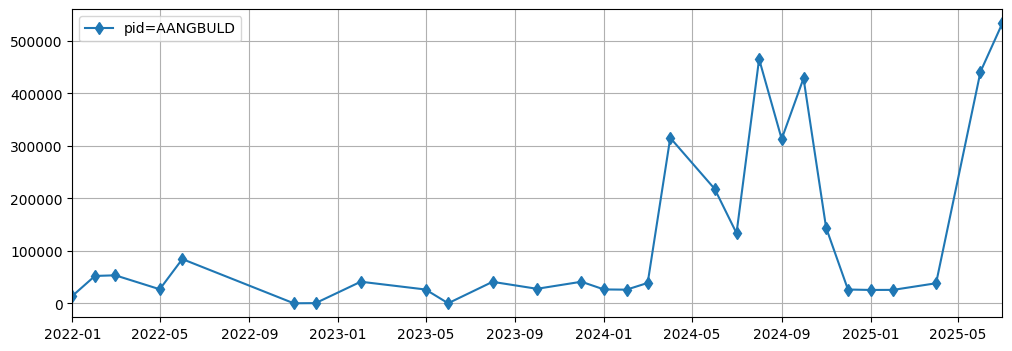

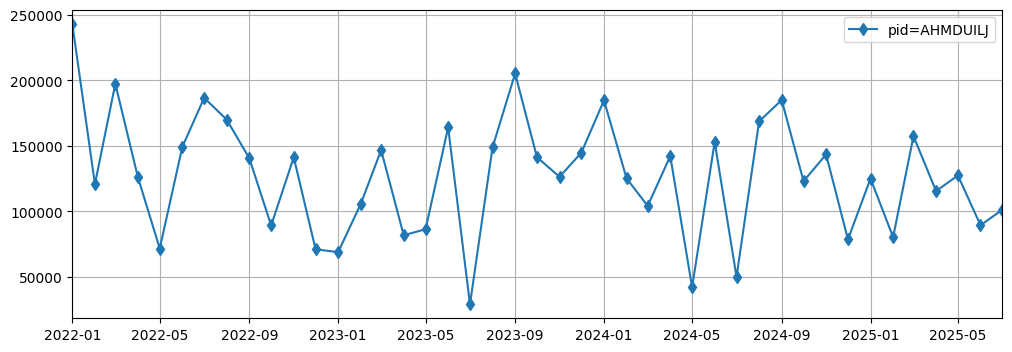

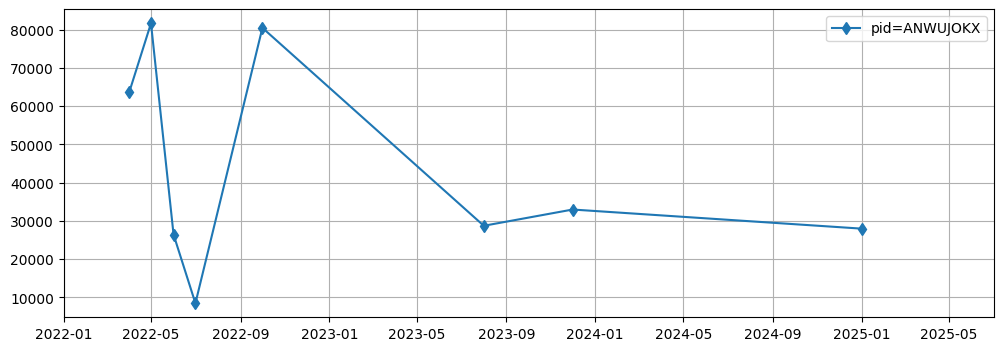

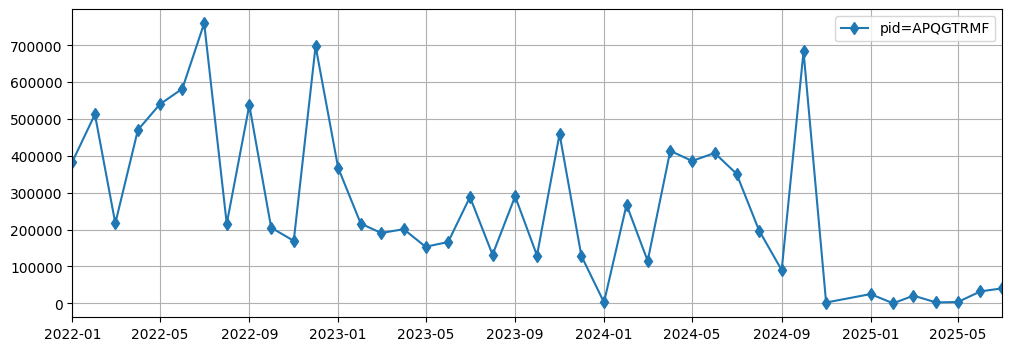

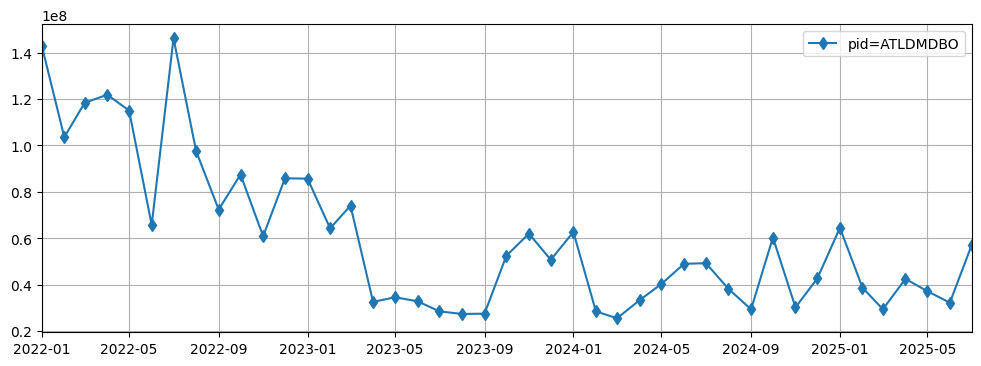

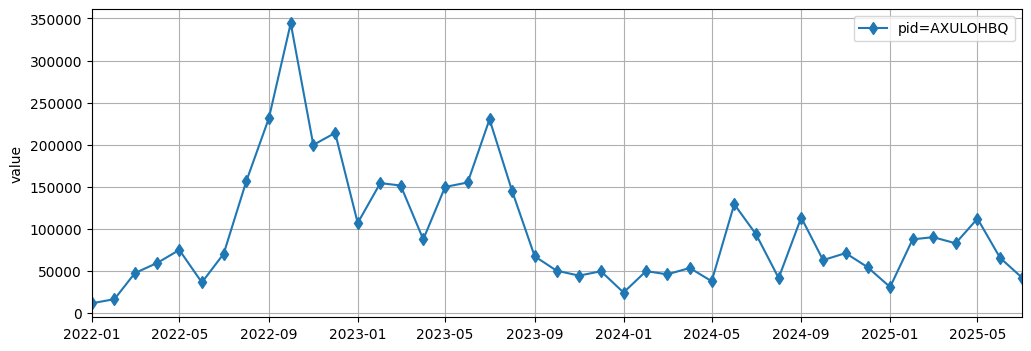

In [47]:
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    print(f'i = {i+1}, item name: {group[0]}')

    fig = plt.figure(figsize=(12,4))

    ax = plt.gca()
    # 상품별 월별 무역량(월 최대 3회 교역)
    ax.plot(group[1]["ym"], group[1]["value"], label=f'pid={group[0]}', marker='d')
    ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
    ax.legend()
    ax.grid()
    if i==5: break


plt.ylabel("value")
plt.show()

top20_hs4 : [2805 3824 8501 2811 8102 8505 3815 2807 7207 2846 3102 2529 8714 1210
 2002 2701 2612 2501 2102 2836]
top1_hs4=2805, 6개 아이템, ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']
index = 10, 1th item, item name: BSRMSVTC
index = 17, 2th item, item name: DJBLNPNC
index = 66, 3th item, item name: RCBZUSIM
index = 76, 4th item, item name: SUOYXCHP
index = 90, 5th item, item name: WQMVCOEM
index = 99, 6th item, item name: ZKENOUDA


,item_id,ym,value
323,BSRMSVTC,2022-01-01,1216269.0
324,BSRMSVTC,2022-02-01,156005.0
325,BSRMSVTC,2022-03-01,801085.0
326,BSRMSVTC,2022-04-01,365605.0
327,BSRMSVTC,2022-05-01,168725.0
...,...,...,...
3728,ZKENOUDA,2025-03-01,319283.0
3729,ZKENOUDA,2025-04-01,443958.0
3730,ZKENOUDA,2025-05-01,329906.0
3731,ZKENOUDA,2025-06-01,461599.0


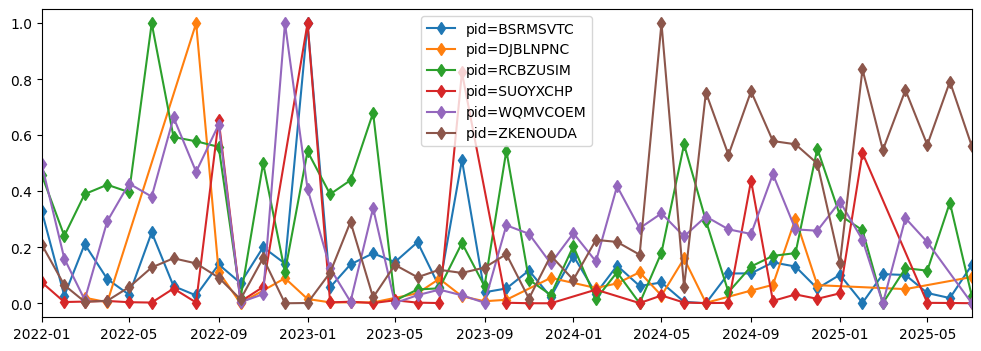

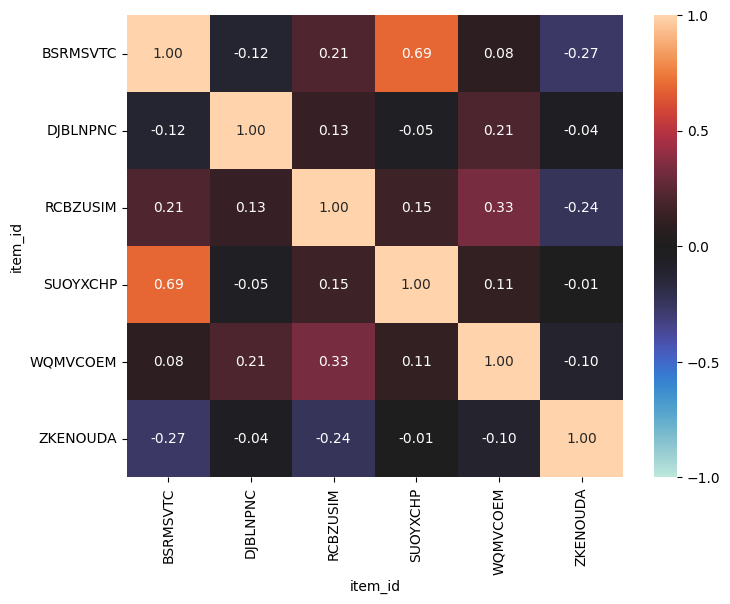

In [52]:
topN_hs4 = hs4_tmp_df['hs4'].values
print(f'top20_hs4 : {topN_hs4[:20]}') # [2805 3824 8501 2811 8102 8505 3815 2807 7207 2846 3102 2529 8714 1210 2002 2701 2612 2501 2102 2836]


sel_topN_hs4 = 1
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')

        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


display(df_hm_plot)
fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f",vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0 )

plt.show()


top2_hs4=3824, 5개 아이템, ['FCYBOAXC' 'IGDVVKUD' 'LPHPPJUG' 'PYZMVUWD' 'SNHYOVBM']
index = 22, 1th item, item name: FCYBOAXC
index = 35, 2th item, item name: IGDVVKUD
index = 45, 3th item, item name: LPHPPJUG
index = 59, 4th item, item name: PYZMVUWD
index = 74, 5th item, item name: SNHYOVBM


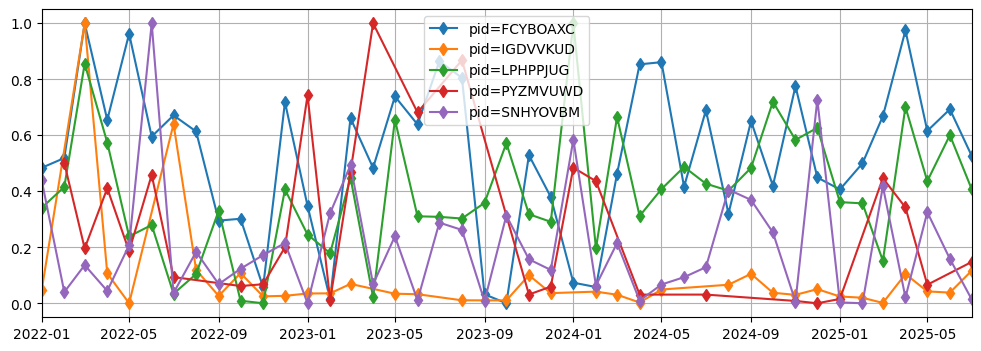

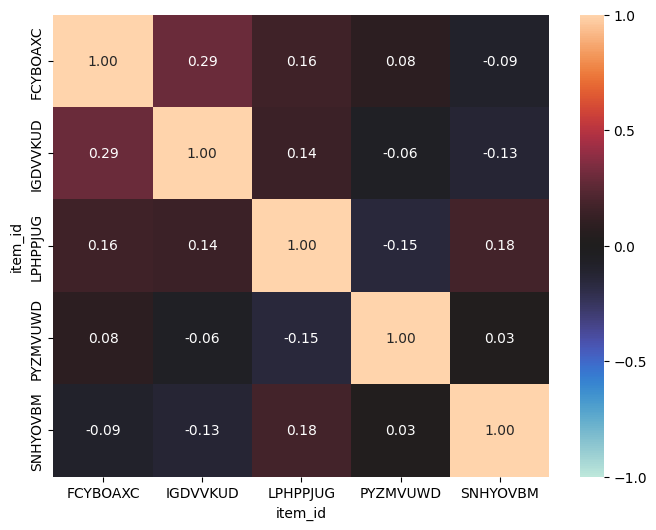

In [53]:
sel_topN_hs4 = 2
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top3_hs4=8501, 5개 아이템, ['GKQIJYDH' 'KFQSHBNH' 'QKXNTIIB' 'RJCAXSGH' 'UQYUIVVR']
index = 30, 1th item, item name: GKQIJYDH
index = 42, 2th item, item name: KFQSHBNH
index = 61, 3th item, item name: QKXNTIIB
index = 67, 4th item, item name: RJCAXSGH
index = 81, 5th item, item name: UQYUIVVR


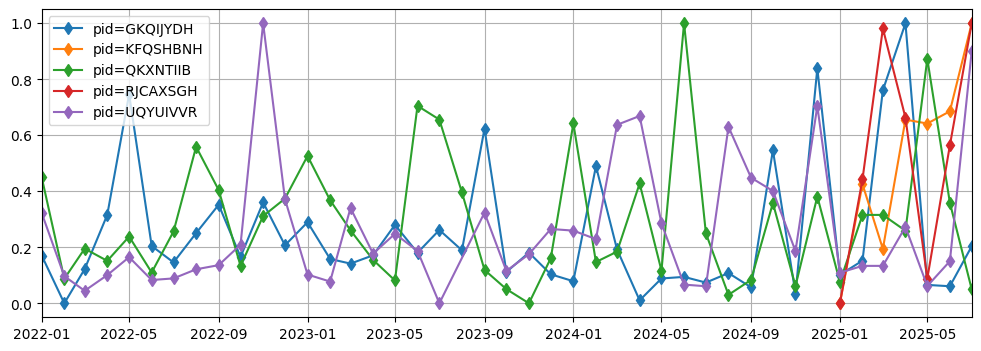

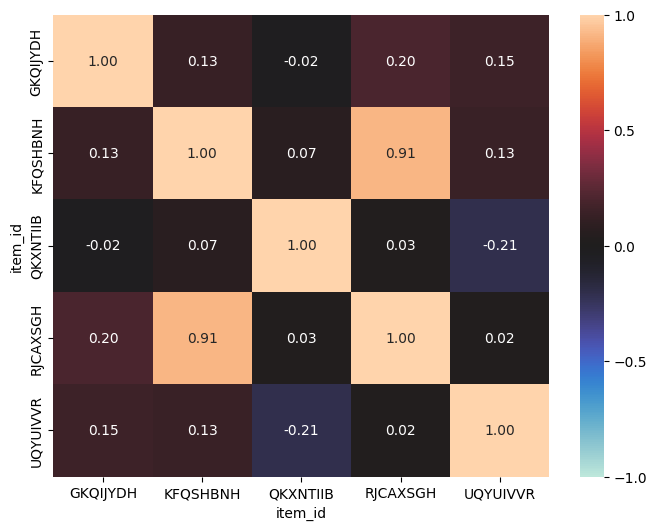

In [54]:
sel_topN_hs4 = 3
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top4_hs4=2811, 4개 아이템, ['DNMPSKTB' 'RJGPVEXX' 'VWMBASNE' 'WPQXWHYO']
index = 18, 1th item, item name: DNMPSKTB
index = 68, 2th item, item name: RJGPVEXX
index = 86, 3th item, item name: VWMBASNE
index = 89, 4th item, item name: WPQXWHYO


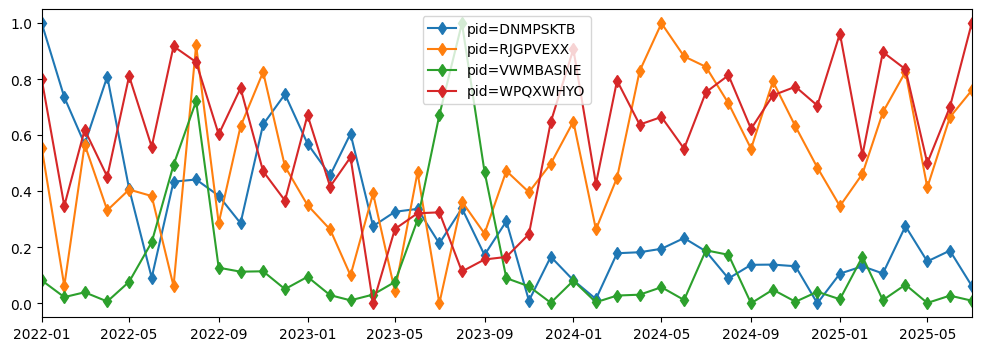

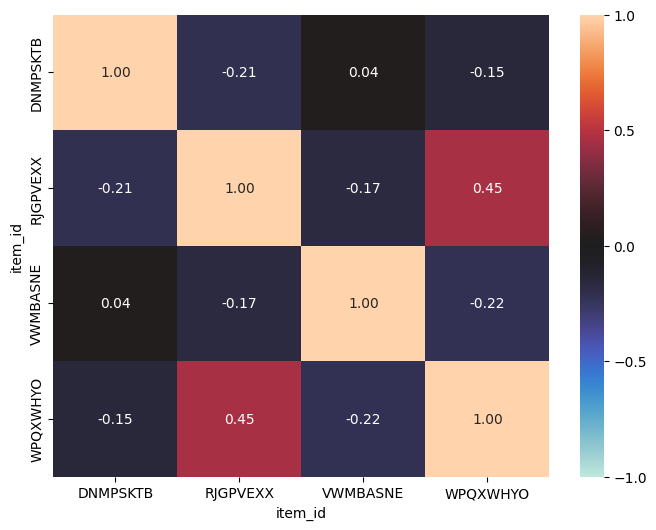

In [55]:
sel_topN_hs4 = 4
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top5_hs4=8102, 3개 아이템, ['FQCLOEXA' 'KEUWZRKO' 'UIFPPCLR']
index = 25, 1th item, item name: FQCLOEXA
index = 41, 2th item, item name: KEUWZRKO
index = 80, 3th item, item name: UIFPPCLR


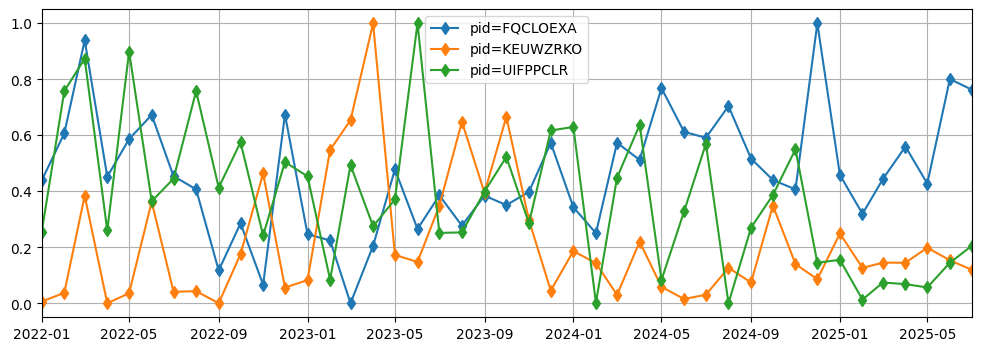

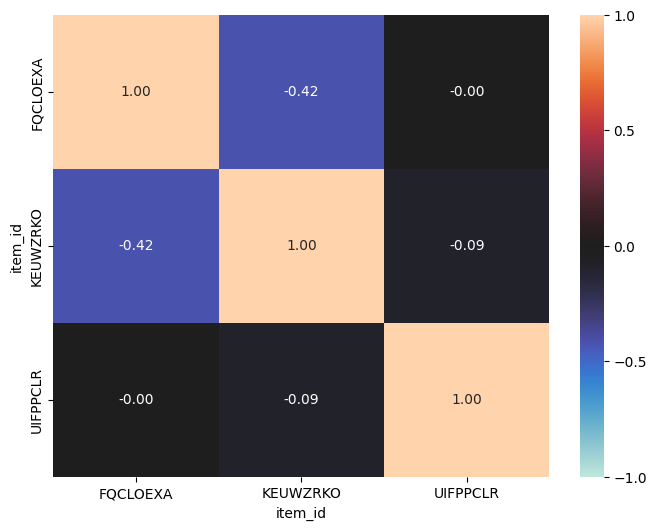

In [56]:
sel_topN_hs4 = 5
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top6_hs4=8505, 3개 아이템, ['GYHKIVQT' 'ROACSLMG' 'VBYCLTYZ']
index = 32, 1th item, item name: GYHKIVQT
index = 69, 2th item, item name: ROACSLMG
index = 83, 3th item, item name: VBYCLTYZ


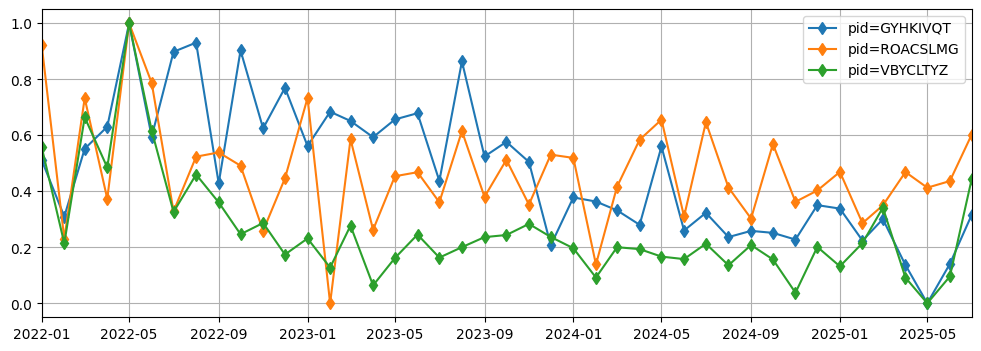

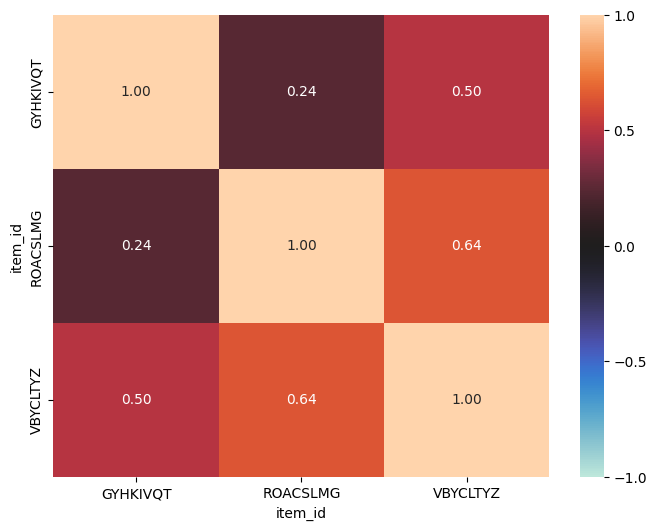

In [57]:
sel_topN_hs4 = 6
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top7_hs4=3815, 3개 아이템, ['OJIFIHMZ' 'STZDBITS' 'XIIEJNEE']
index = 55, 1th item, item name: OJIFIHMZ
index = 75, 2th item, item name: STZDBITS
index = 92, 3th item, item name: XIIEJNEE


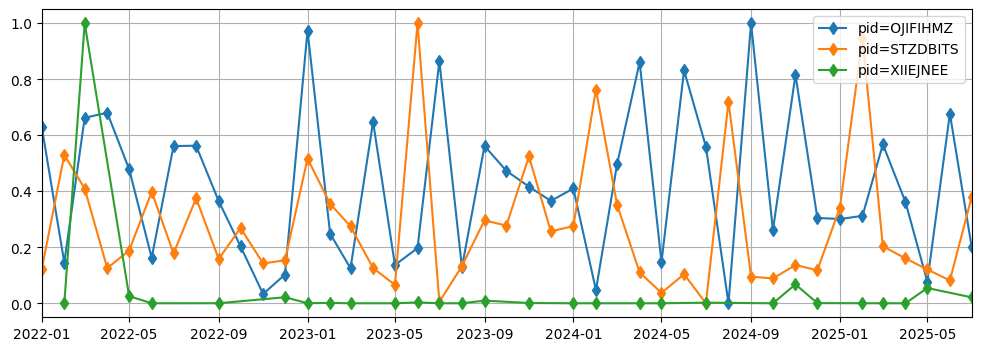

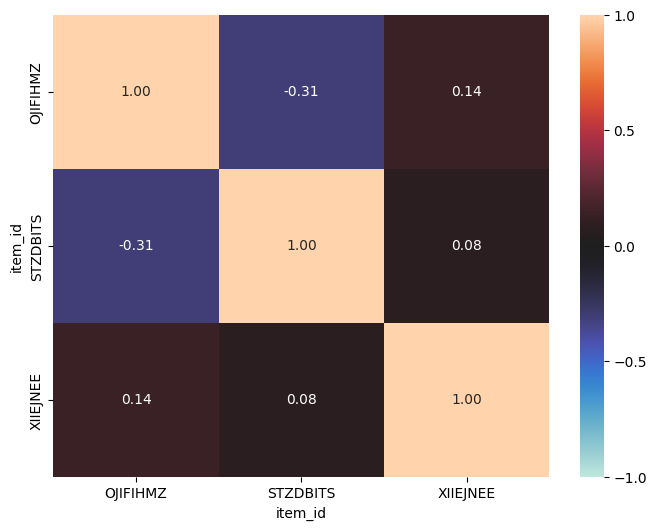

In [58]:
sel_topN_hs4 = 7
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top8_hs4=2807, 3개 아이템, ['DDEXPPXU' 'LLHREMKS' 'YSYHGLQK']
index = 15, 1th item, item name: DDEXPPXU
index = 44, 2th item, item name: LLHREMKS
index = 96, 3th item, item name: YSYHGLQK


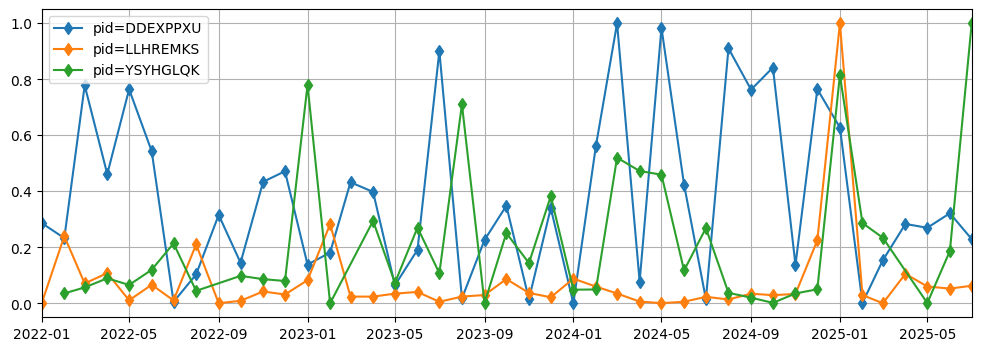

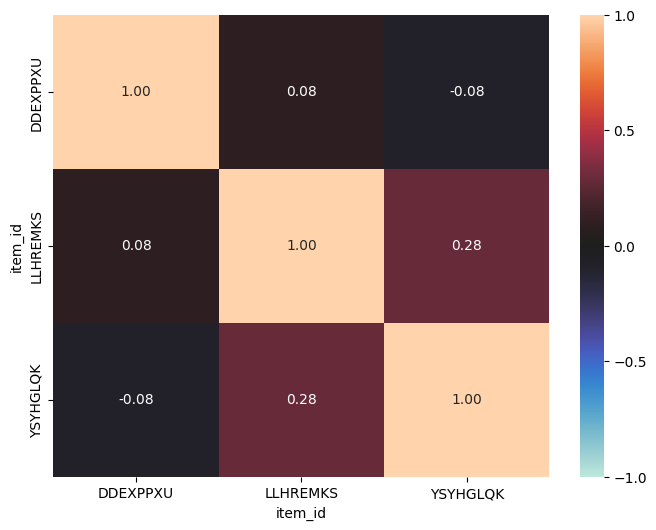

In [59]:
sel_topN_hs4 = 8
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top9_hs4=7207, 2개 아이템, ['SDWAYPIK' 'TGOELCAG']
index = 73, 1th item, item name: SDWAYPIK
index = 78, 2th item, item name: TGOELCAG


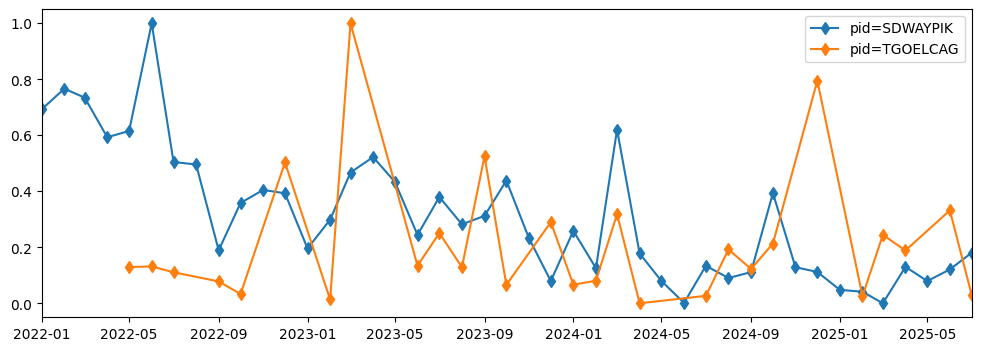

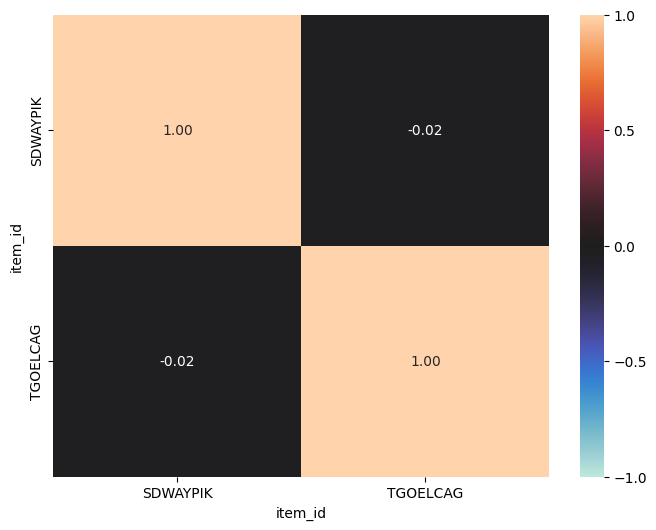

In [60]:
sel_topN_hs4 = 9
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top10_hs4=2846, 2개 아이템, ['FRHNWLNI' 'MBSBZBXA']
index = 26, 1th item, item name: FRHNWLNI
index = 50, 2th item, item name: MBSBZBXA


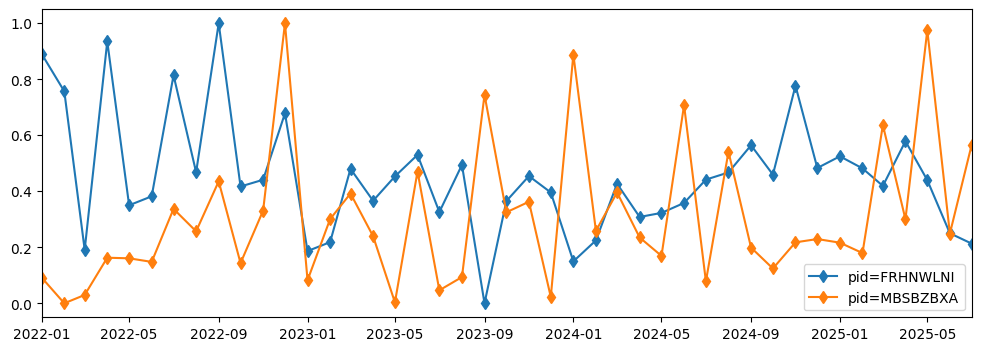

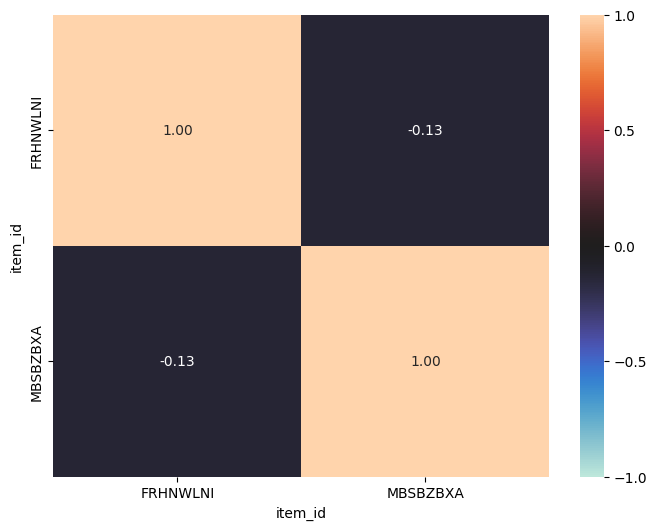

In [61]:
sel_topN_hs4 = 10
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top11_hs4=3102, 2개 아이템, ['BTMOEMEP' 'LRVGFDFM']
index = 11, 1th item, item name: BTMOEMEP
index = 46, 2th item, item name: LRVGFDFM


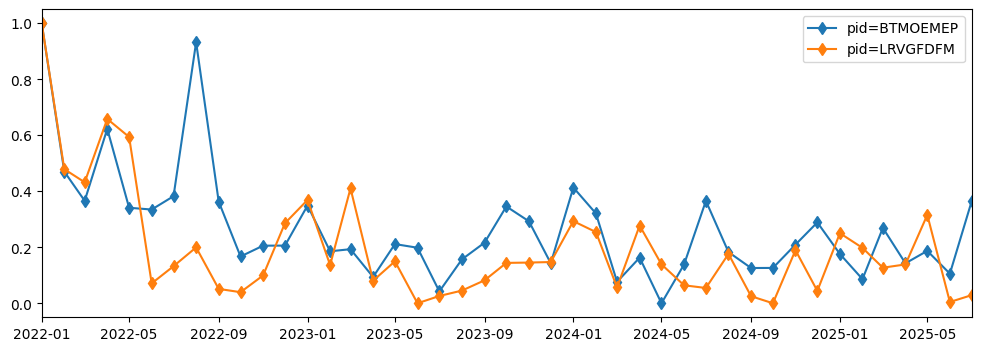

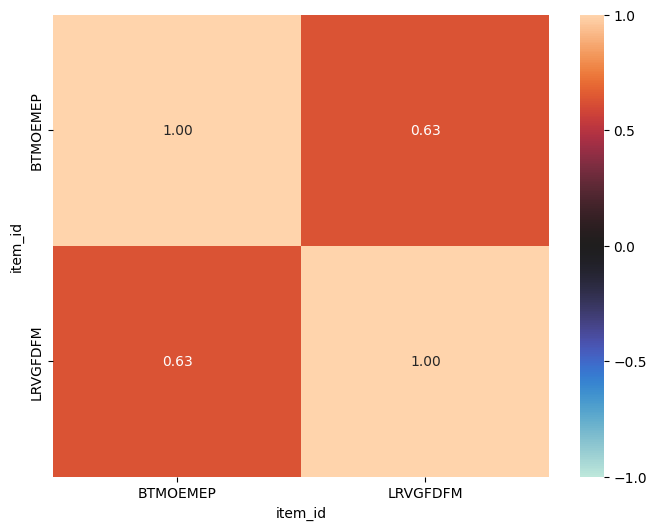

In [62]:
sel_topN_hs4 = 11
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top12_hs4=2529, 2개 아이템, ['FTSVTTSR' 'XMKRPGLB']
index = 27, 1th item, item name: FTSVTTSR
index = 94, 2th item, item name: XMKRPGLB


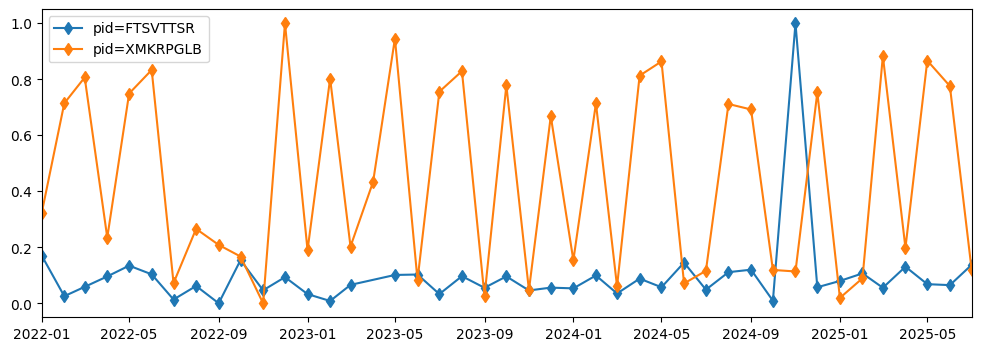

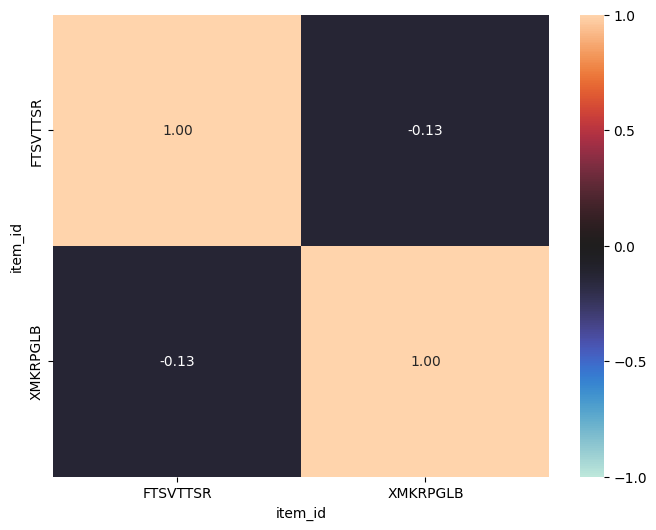

In [63]:
sel_topN_hs4 = 12
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

top13_hs4=8714, 2개 아이템, ['FITUEHWN' 'UGEQLMXM']
index = 24, 1th item, item name: FITUEHWN
index = 79, 2th item, item name: UGEQLMXM


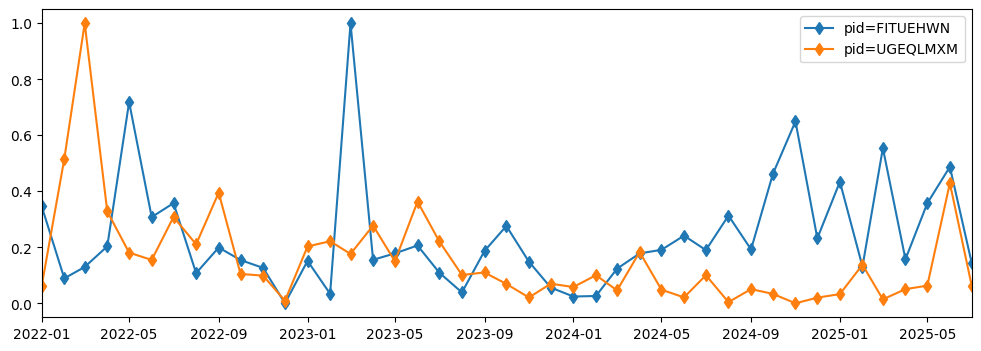

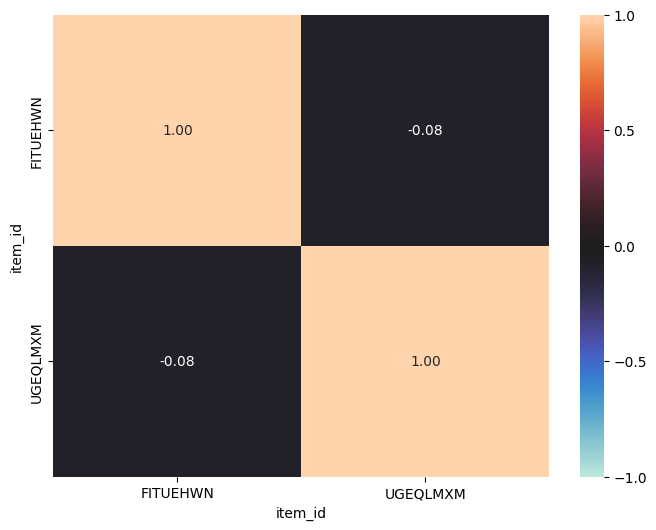

In [64]:
sel_topN_hs4 = 13
print(f'top{sel_topN_hs4}_hs4={topN_hs4[sel_topN_hs4-1]}, {len(dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]])}개 아이템, {dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_hs4_tmp_df[topN_hs4[sel_topN_hs4-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')
        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f", vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0)
plt.show()

In [66]:
train_df.groupby('seq')['item_id'].apply(lambda x: len(set(x)))

,item_id
seq,
1.0,99
2.0,100
3.0,100


In [67]:
train_df[train_df['seq'] == 1.]['item_id'].unique().shape, \
train_df[train_df['seq'] == 2.]['item_id'].unique().shape, \
train_df[train_df['seq'] == 3.]['item_id'].unique().shape

((99,), (100,), (100,))

In [68]:
train_df[train_df['seq'] == 1.]['year'].unique().shape, \
train_df[train_df['seq'] == 2.]['year'].unique().shape, \
train_df[train_df['seq'] == 3.]['year'].unique().shape

((4,), (4,), (4,))

In [69]:
train_df[train_df['seq'] == 1.]['month'].unique().shape, \
train_df[train_df['seq'] == 2.]['month'].unique().shape, \
train_df[train_df['seq'] == 3.]['month'].unique().shape

((12,), (12,), (12,))

In [70]:
pd.pivot_table(train_df,
               index='item_id',
               columns='year',
               values='seq',
               aggfunc='sum')

year,2022,2023,2024,2025
item_id,,,,
AANGBULD,30.0,29.0,57.0,19.0
AHMDUILJ,72.0,72.0,72.0,42.0
ANWUJOKX,25.0,9.0,NaN,6.0
APQGTRMF,69.0,67.0,62.0,41.0
ATLDMDBO,69.0,72.0,71.0,42.0
...,...,...,...,...
YSYHGLQK,56.0,62.0,62.0,30.0
ZCELVYQU,62.0,65.0,53.0,40.0
ZGJXVMNI,72.0,72.0,72.0,42.0


In [73]:
seq_pivot_df_cnt = pd.pivot_table(train_df,
                                  index='item_id',
                                  columns="month",
                                  values='seq',
                                  aggfunc='count',
                                  margins=True,
                                  margins_name="seq_total")
seq_pivot_df_cnt

month,1,2,3,4,5,6,7,8,9,10,11,12,seq_total
item_id,,,,,,,,,,,,,
AANGBULD,5.0,8.0,5.0,3.0,4.0,7.0,5.0,4.0,3.0,4.0,3.0,5.0,56
AHMDUILJ,12.0,12.0,12.0,12.0,12.0,12.0,12.0,9.0,9.0,9.0,9.0,9.0,129
ANWUJOKX,3.0,NaN,NaN,3.0,3.0,1.0,2.0,1.0,NaN,2.0,NaN,3.0,18
APQGTRMF,12.0,11.0,10.0,11.0,12.0,11.0,12.0,7.0,9.0,7.0,8.0,5.0,115
ATLDMDBO,12.0,12.0,11.0,12.0,12.0,11.0,11.0,9.0,9.0,9.0,8.0,9.0,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZCELVYQU,10.0,10.0,9.0,12.0,10.0,11.0,11.0,3.0,7.0,6.0,7.0,9.0,105
ZGJXVMNI,12.0,12.0,12.0,12.0,12.0,12.0,12.0,9.0,9.0,9.0,9.0,9.0,129
ZKENOUDA,11.0,12.0,12.0,12.0,12.0,12.0,12.0,9.0,9.0,8.0,9.0,8.0,126


count : [ 4.  1.  4.  0.  0.  0.  0.  1.  2.  3.  3.  1.  0.  1.  3.  1.  2.  5.
  4. 65.]
bins : [  2.     8.35  14.7   21.05  27.4   33.75  40.1   46.45  52.8   59.15
  65.5   71.85  78.2   84.55  90.9   97.25 103.6  109.95 116.3  122.65
 129.  ]
container : <BarContainer object of 20 artists>
2.0 ~ 8.35 : 4개
8.35 ~ 14.7 : 1개
14.7 ~ 21.049999999999997 : 4개
21.049999999999997 ~ 27.4 : 0개
27.4 ~ 33.75 : 0개
33.75 ~ 40.099999999999994 : 0개
40.099999999999994 ~ 46.449999999999996 : 0개
46.449999999999996 ~ 52.8 : 1개


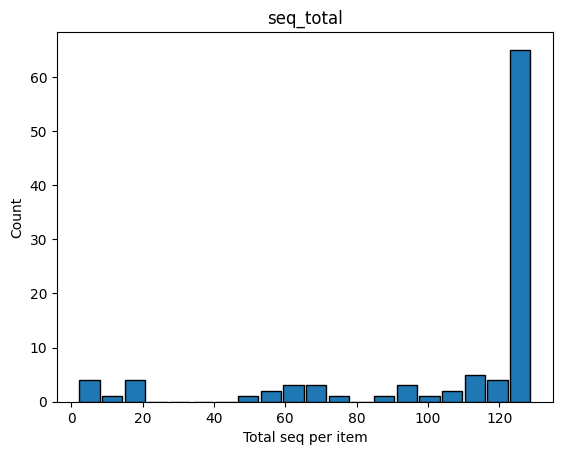

In [76]:
count, bins, container = plt.hist(seq_pivot_df_cnt['seq_total'].iloc[:-1],
                                  bins=20,
                                  edgecolor='k',
                                  rwidth=.9)
print('count :', count)
print('bins :', bins)
print('container :', container)


for i in range(8):
    print(f'{bins[i]} ~ {bins[i+1]} : {int(count[i])}개')

plt.xlabel('Total seq per item')
plt.ylabel('Count')

plt.title("seq_total")
plt.show()


In [77]:
tmp_ser = seq_pivot_df_cnt['seq_total'].iloc[:-1]
dct_seq_total = pd.cut(tmp_ser, bins= [0, 40, 80, tmp_ser.max()], labels = ['seq_cnt_low',  'seq_cnt_mid',  'seq_cnt_high'] ).to_dict()
dct_seq_total

{'AANGBULD': 'seq_cnt_mid',
 'AHMDUILJ': 'seq_cnt_high',
 'ANWUJOKX': 'seq_cnt_low',
 'APQGTRMF': 'seq_cnt_high',
 'ATLDMDBO': 'seq_cnt_high',
 'AXULOHBQ': 'seq_cnt_high',
 'BEZYMBBT': 'seq_cnt_high',
 'BJALXPFS': 'seq_cnt_high',
 'BLANHGYY': 'seq_cnt_mid',
 'BSRMSVTC': 'seq_cnt_high',
 'BTMOEMEP': 'seq_cnt_high',
 'BUZIIBYG': 'seq_cnt_high',
 'CCLHWFWF': 'seq_cnt_high',
 'DBWLZWNK': 'seq_cnt_high',
 'DDEXPPXU': 'seq_cnt_high',
 'DEWLVASR': 'seq_cnt_high',
 'DJBLNPNC': 'seq_cnt_mid',
 'DNMPSKTB': 'seq_cnt_high',
 'DUCMGGNW': 'seq_cnt_high',
 'ELQGMQWE': 'seq_cnt_high',
 'EVBVXETX': 'seq_cnt_high',
 'FCYBOAXC': 'seq_cnt_high',
 'FDXPMYGF': 'seq_cnt_high',
 'FITUEHWN': 'seq_cnt_high',
 'FQCLOEXA': 'seq_cnt_high',
 'FRHNWLNI': 'seq_cnt_high',
 'FTSVTTSR': 'seq_cnt_high',
 'FWUCPMMW': 'seq_cnt_mid',
 'GIKPEWTY': 'seq_cnt_low',
 'GKQIJYDH': 'seq_cnt_high',
 'GMBFCMIU': 'seq_cnt_low',
 'GYHKIVQT': 'seq_cnt_high',
 'HCDTGMST': 'seq_cnt_high',
 'HXYSSRXE': 'seq_cnt_high',
 'IGDVVKUD': 'seq_cnt

In [78]:
train_fe = train_df.copy()
train_fe['seq_cat'] = train_fe["item_id"].map(dct_seq_total)
train_fe

,item_id,year,month,seq,type,hs4,weight,quantity,value,seq_cat
0,DEWLVASR,2022,1,1.0,1,3038,14858.0,0.0,32688.0,seq_cnt_high
1,ELQGMQWE,2022,1,1.0,1,2002,62195.0,0.0,110617.0,seq_cnt_high
2,AHMDUILJ,2022,1,1.0,1,2102,18426.0,0.0,72766.0,seq_cnt_high
3,XIPPENFQ,2022,1,1.0,1,2501,20426.0,0.0,11172.0,seq_cnt_high
4,FTSVTTSR,2022,1,1.0,1,2529,248000.0,0.0,143004.0,seq_cnt_high
...,...,...,...,...,...,...,...,...,...,...
10831,XIFHSOWQ,2025,7,3.0,1,8708,352.0,0.0,12937.0,seq_cnt_high
10832,FITUEHWN,2025,7,3.0,1,8714,655.0,900.0,16054.0,seq_cnt_high
10833,UGEQLMXM,2025,7,3.0,1,8714,758.0,0.0,74377.0,seq_cnt_high
10834,BLANHGYY,2025,7,3.0,1,9022,345.0,2.0,69720.0,seq_cnt_mid


In [79]:
monthly_fe = monthly.copy()
monthly_fe["seq_cat"] = monthly_fe['item_id'].map(dct_seq_total)
monthly_fe

,item_id,year,month,value,ym,seq_cat
0,AANGBULD,2022,1,14276.0,2022-01-01,seq_cnt_mid
1,AANGBULD,2022,2,52347.0,2022-02-01,seq_cnt_mid
2,AANGBULD,2022,3,53549.0,2022-03-01,seq_cnt_mid
3,AANGBULD,2022,5,26997.0,2022-05-01,seq_cnt_mid
4,AANGBULD,2022,6,84489.0,2022-06-01,seq_cnt_mid
...,...,...,...,...,...,...
3771,ZXERAXWP,2025,3,12817.0,2025-03-01,seq_cnt_high
3772,ZXERAXWP,2025,4,12482.0,2025-04-01,seq_cnt_high
3773,ZXERAXWP,2025,5,18224.0,2025-05-01,seq_cnt_high
3774,ZXERAXWP,2025,6,42690.0,2025-06-01,seq_cnt_high


In [80]:
train_fe.groupby(["seq_cat"], as_index=False)["item_id"].apply(lambda x: np.unique(x))

,seq_cat,item_id
0,seq_cnt_high,"[AHMDUILJ, APQGTRMF, ATLDMDBO, AXULOHBQ, BEZYM..."
1,seq_cnt_low,"[ANWUJOKX, GIKPEWTY, GMBFCMIU, KFQSHBNH, PLMZA..."
2,seq_cnt_mid,"[AANGBULD, BLANHGYY, DJBLNPNC, FWUCPMMW, MIRCV..."


In [82]:
tmp_df_seq = train_fe.groupby(["seq_cat"], as_index=False)["item_id"].apply(lambda x: np.unique(x))
tmp_df_seq['seq_cat_len'] = train_fe.groupby(["seq_cat"])["item_id"].apply(lambda x: len(np.unique(x))).values
tmp_df_seq

,seq_cat,item_id,seq_cat_len
0,seq_cnt_high,"[AHMDUILJ, APQGTRMF, ATLDMDBO, AXULOHBQ, BEZYM...",81
1,seq_cnt_low,"[ANWUJOKX, GIKPEWTY, GMBFCMIU, KFQSHBNH, PLMZA...",9
2,seq_cnt_mid,"[AANGBULD, BLANHGYY, DJBLNPNC, FWUCPMMW, MIRCV...",10


In [83]:
dct_seq_cat = tmp_df_seq[['seq_cat','item_id']].set_index('seq_cat').to_dict()['item_id']
dct_seq_cat

{'seq_cnt_high': array(['AHMDUILJ', 'APQGTRMF', 'ATLDMDBO', 'AXULOHBQ', 'BEZYMBBT',
        'BJALXPFS', 'BSRMSVTC', 'BTMOEMEP', 'BUZIIBYG', 'CCLHWFWF',
        'DBWLZWNK', 'DDEXPPXU', 'DEWLVASR', 'DNMPSKTB', 'DUCMGGNW',
        'ELQGMQWE', 'EVBVXETX', 'FCYBOAXC', 'FDXPMYGF', 'FITUEHWN',
        'FQCLOEXA', 'FRHNWLNI', 'FTSVTTSR', 'GKQIJYDH', 'GYHKIVQT',
        'HCDTGMST', 'HXYSSRXE', 'IGDVVKUD', 'JBVHSUWY', 'JERHKLYW',
        'JPBRUTWP', 'JSLXRQOK', 'KAGJCHMR', 'KEUWZRKO', 'KJNSOAHR',
        'LLHREMKS', 'LPHPPJUG', 'LRVGFDFM', 'LSOIUSXD', 'LTOYKIML',
        'LUENUFGA', 'MBSBZBXA', 'NZKBIBNU', 'OJIFIHMZ', 'OKMBFVKS',
        'OXKURKXR', 'QJQJSWFU', 'QKXNTIIB', 'QRKRBYJL', 'QVLMOEYE',
        'RAWUKQMJ', 'RCBZUSIM', 'RJGPVEXX', 'ROACSLMG', 'SAAYMURU',
        'SAHWCZNH', 'SDWAYPIK', 'SNHYOVBM', 'STZDBITS', 'SUOYXCHP',
        'UGEQLMXM', 'UIFPPCLR', 'UQYUIVVR', 'UXSPKBJR', 'VBYCLTYZ',
        'VMAQSTJE', 'VUAFAIYJ', 'VWMBASNE', 'WBLJNPZQ', 'WHPUAOID',
        'WPQXWHYO', 'WQMVCOEM', 

In [84]:
topN_seq_cat = tmp_df_seq['seq_cat'].values
topN_seq_cat

array(['seq_cnt_high', 'seq_cnt_low', 'seq_cnt_mid'], dtype=object)

top1_seq_cat=seq_cnt_high, 81개 아이템, ['AHMDUILJ' 'APQGTRMF' 'ATLDMDBO' 'AXULOHBQ' 'BEZYMBBT' 'BJALXPFS'
 'BSRMSVTC' 'BTMOEMEP' 'BUZIIBYG' 'CCLHWFWF' 'DBWLZWNK' 'DDEXPPXU'
 'DEWLVASR' 'DNMPSKTB' 'DUCMGGNW' 'ELQGMQWE' 'EVBVXETX' 'FCYBOAXC'
 'FDXPMYGF' 'FITUEHWN' 'FQCLOEXA' 'FRHNWLNI' 'FTSVTTSR' 'GKQIJYDH'
 'GYHKIVQT' 'HCDTGMST' 'HXYSSRXE' 'IGDVVKUD' 'JBVHSUWY' 'JERHKLYW'
 'JPBRUTWP' 'JSLXRQOK' 'KAGJCHMR' 'KEUWZRKO' 'KJNSOAHR' 'LLHREMKS'
 'LPHPPJUG' 'LRVGFDFM' 'LSOIUSXD' 'LTOYKIML' 'LUENUFGA' 'MBSBZBXA'
 'NZKBIBNU' 'OJIFIHMZ' 'OKMBFVKS' 'OXKURKXR' 'QJQJSWFU' 'QKXNTIIB'
 'QRKRBYJL' 'QVLMOEYE' 'RAWUKQMJ' 'RCBZUSIM' 'RJGPVEXX' 'ROACSLMG'
 'SAAYMURU' 'SAHWCZNH' 'SDWAYPIK' 'SNHYOVBM' 'STZDBITS' 'SUOYXCHP'
 'UGEQLMXM' 'UIFPPCLR' 'UQYUIVVR' 'UXSPKBJR' 'VBYCLTYZ' 'VMAQSTJE'
 'VUAFAIYJ' 'VWMBASNE' 'WBLJNPZQ' 'WHPUAOID' 'WPQXWHYO' 'WQMVCOEM'
 'XIFHSOWQ' 'XIPPENFQ' 'XMKRPGLB' 'XUOIQPFL' 'YSYHGLQK' 'ZCELVYQU'
 'ZGJXVMNI' 'ZKENOUDA' 'ZXERAXWP']


,item_id,ym,value
29,AHMDUILJ,2022-01-01,242705.0
30,AHMDUILJ,2022-02-01,120847.0
31,AHMDUILJ,2022-03-01,197317.0
32,AHMDUILJ,2022-04-01,126142.0
33,AHMDUILJ,2022-05-01,71730.0
...,...,...,...
3771,ZXERAXWP,2025-03-01,12817.0
3772,ZXERAXWP,2025-04-01,12482.0
3773,ZXERAXWP,2025-05-01,18224.0
3774,ZXERAXWP,2025-06-01,42690.0


<Axes: xlabel='item_id', ylabel='item_id'>

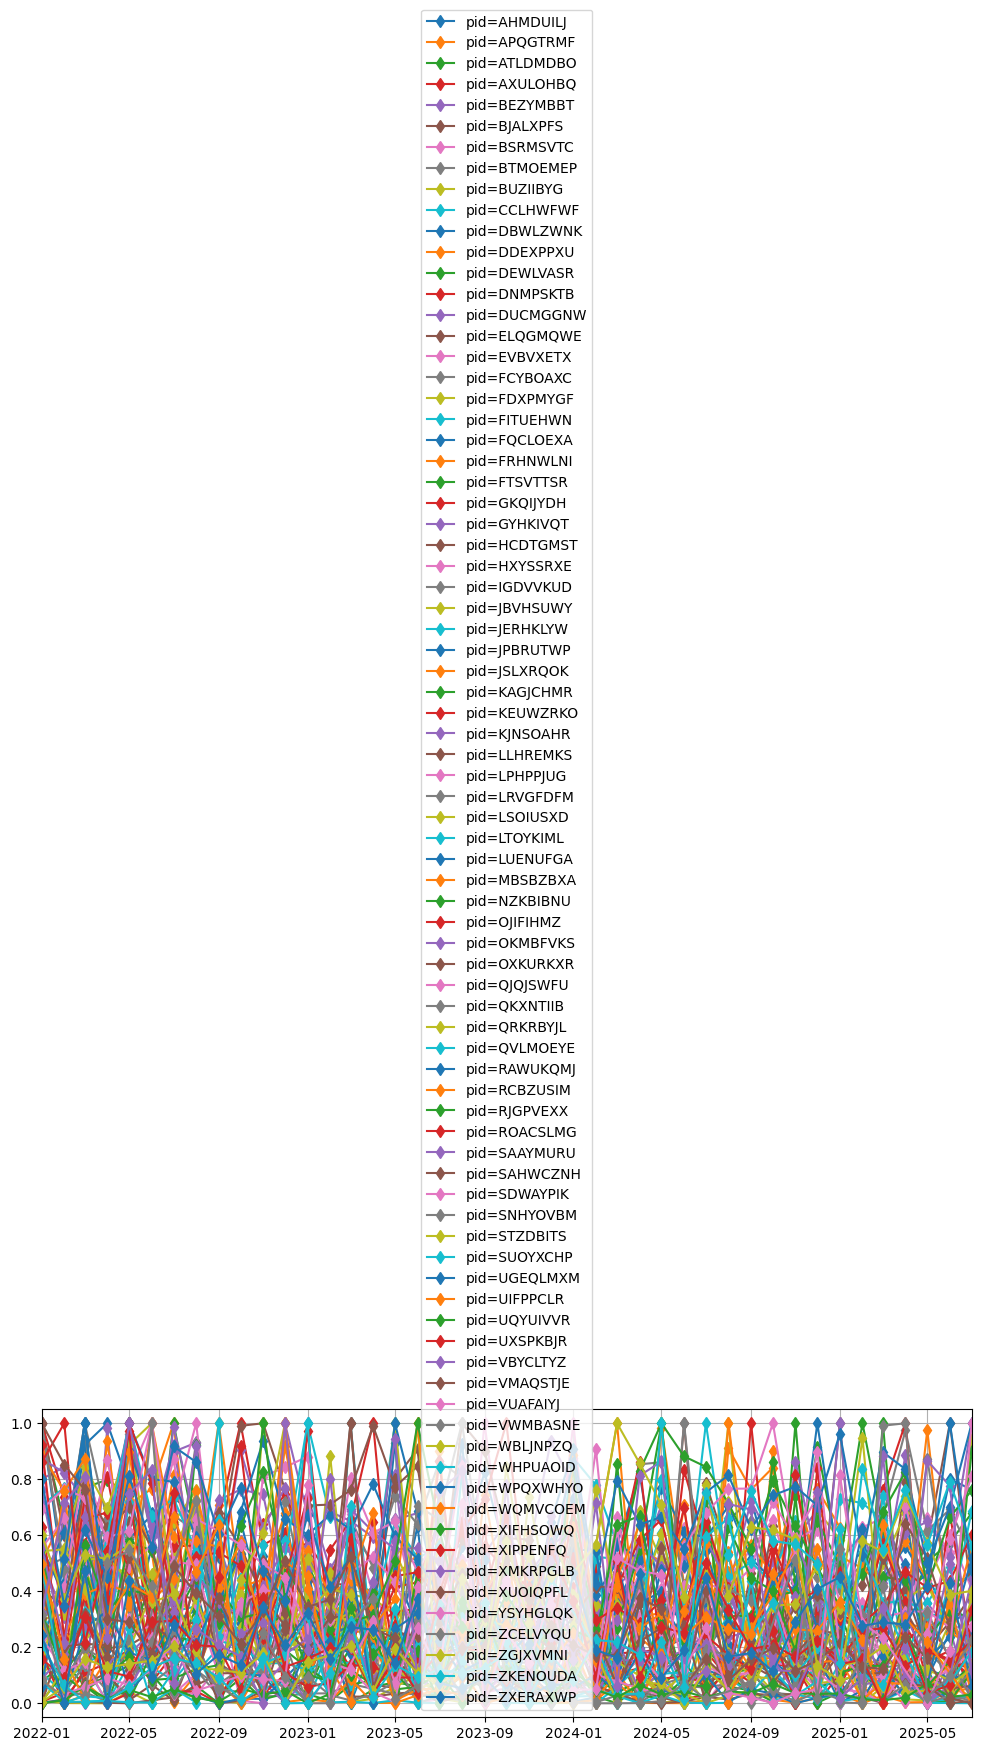

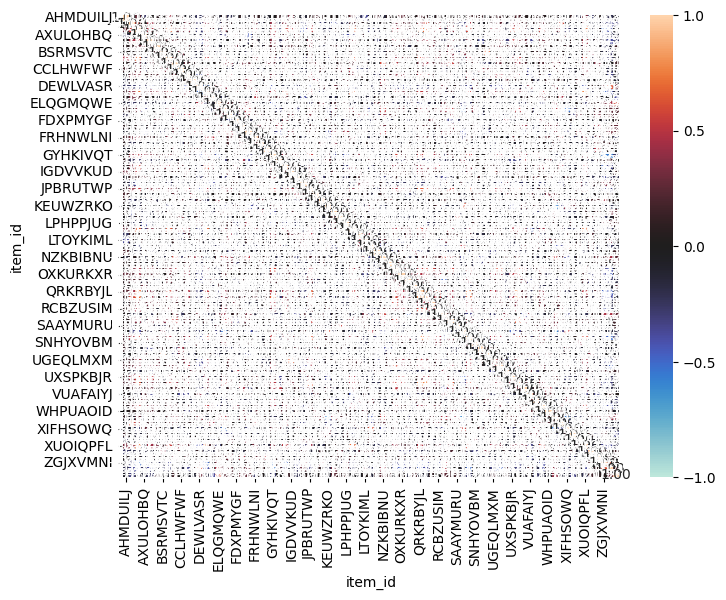

In [85]:
###
### sel_topN_seq_cat = 1 경우
###

sel_topN_seq_cat = 1
print(f'top{sel_topN_seq_cat}_seq_cat={topN_seq_cat[sel_topN_seq_cat-1]}, {len(dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]])}개 아이템, {dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]]:
        j += 1

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')

        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()


display(df_hm_plot)
fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot,
                         index='ym',
                         columns='item_id',
                         values='value',
                         fill_value=0).corr()
sns.heatmap(corr_mat,
            annot=True,
            fmt=".2f",
            vmin=-1,
            vmax=1,
            cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]},
            center=0)

In [86]:
corr_mat[corr_mat.abs() > 0.5]

item_id,AHMDUILJ,APQGTRMF,ATLDMDBO,AXULOHBQ,BEZYMBBT,BJALXPFS,BSRMSVTC,BTMOEMEP,BUZIIBYG,CCLHWFWF,...,WQMVCOEM,XIFHSOWQ,XIPPENFQ,XMKRPGLB,XUOIQPFL,YSYHGLQK,ZCELVYQU,ZGJXVMNI,ZKENOUDA,ZXERAXWP
item_id,,,,,,,,,,,,,,,,,,,,,
AHMDUILJ,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
APQGTRMF,NaN,1.000000,0.548979,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.586799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ATLDMDBO,NaN,0.548979,1.000000,NaN,NaN,NaN,NaN,0.686812,NaN,NaN,...,NaN,NaN,NaN,NaN,0.707539,NaN,NaN,-0.528831,NaN,NaN
AXULOHBQ,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BEZYMBBT,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YSYHGLQK,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN
ZCELVYQU,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN
ZGJXVMNI,NaN,NaN,-0.528831,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.616375,NaN


In [88]:
# corr()값이 높은 pair를 필터링 하기위함
high_corr = []
for i, row in enumerate(corr_mat[(corr_mat.abs() > 0.6) & corr_mat[(corr_mat.abs() < 0.99)]].iterrows()):
    if row[1].any():
        print((row[1][row[1].notna()].name, row[1][row[1].notna()].index.to_list()))
        high_corr.append((row[1][row[1].notna()].name, row[1][row[1].notna()].index.to_list()))

('ATLDMDBO', ['BTMOEMEP', 'DNMPSKTB', 'LRVGFDFM', 'QRKRBYJL', 'QVLMOEYE', 'VBYCLTYZ', 'XUOIQPFL'])
('BSRMSVTC', ['SUOYXCHP'])
('BTMOEMEP', ['ATLDMDBO', 'LRVGFDFM'])
('DEWLVASR', ['ZKENOUDA'])
('DNMPSKTB', ['ATLDMDBO', 'LRVGFDFM', 'XUOIQPFL'])
('GYHKIVQT', ['QVLMOEYE'])
('IGDVVKUD', ['UGEQLMXM'])
('JPBRUTWP', ['QRKRBYJL', 'SDWAYPIK', 'VBYCLTYZ'])
('KEUWZRKO', ['SAHWCZNH'])
('LRVGFDFM', ['ATLDMDBO', 'BTMOEMEP', 'DNMPSKTB', 'XUOIQPFL'])
('LUENUFGA', ['XIFHSOWQ'])
('QRKRBYJL', ['ATLDMDBO', 'JPBRUTWP', 'QVLMOEYE', 'SDWAYPIK', 'VBYCLTYZ'])
('QVLMOEYE', ['ATLDMDBO', 'GYHKIVQT', 'QRKRBYJL', 'SDWAYPIK', 'VBYCLTYZ'])
('ROACSLMG', ['VBYCLTYZ'])
('SAHWCZNH', ['KEUWZRKO', 'WPQXWHYO'])
('SDWAYPIK', ['JPBRUTWP', 'QRKRBYJL', 'QVLMOEYE'])
('SUOYXCHP', ['BSRMSVTC'])
('UGEQLMXM', ['IGDVVKUD'])
('VBYCLTYZ', ['ATLDMDBO', 'JPBRUTWP', 'QRKRBYJL', 'QVLMOEYE', 'ROACSLMG'])
('WPQXWHYO', ['SAHWCZNH'])
('XIFHSOWQ', ['LUENUFGA'])
('XUOIQPFL', ['ATLDMDBO', 'DNMPSKTB', 'LRVGFDFM'])
('ZGJXVMNI', ['ZKENOUDA'])
('ZKENO

In [89]:
dict_hight_corr = dict(high_corr)
dict_hight_corr

{'ATLDMDBO': ['BTMOEMEP',
  'DNMPSKTB',
  'LRVGFDFM',
  'QRKRBYJL',
  'QVLMOEYE',
  'VBYCLTYZ',
  'XUOIQPFL'],
 'BSRMSVTC': ['SUOYXCHP'],
 'BTMOEMEP': ['ATLDMDBO', 'LRVGFDFM'],
 'DEWLVASR': ['ZKENOUDA'],
 'DNMPSKTB': ['ATLDMDBO', 'LRVGFDFM', 'XUOIQPFL'],
 'GYHKIVQT': ['QVLMOEYE'],
 'IGDVVKUD': ['UGEQLMXM'],
 'JPBRUTWP': ['QRKRBYJL', 'SDWAYPIK', 'VBYCLTYZ'],
 'KEUWZRKO': ['SAHWCZNH'],
 'LRVGFDFM': ['ATLDMDBO', 'BTMOEMEP', 'DNMPSKTB', 'XUOIQPFL'],
 'LUENUFGA': ['XIFHSOWQ'],
 'QRKRBYJL': ['ATLDMDBO', 'JPBRUTWP', 'QVLMOEYE', 'SDWAYPIK', 'VBYCLTYZ'],
 'QVLMOEYE': ['ATLDMDBO', 'GYHKIVQT', 'QRKRBYJL', 'SDWAYPIK', 'VBYCLTYZ'],
 'ROACSLMG': ['VBYCLTYZ'],
 'SAHWCZNH': ['KEUWZRKO', 'WPQXWHYO'],
 'SDWAYPIK': ['JPBRUTWP', 'QRKRBYJL', 'QVLMOEYE'],
 'SUOYXCHP': ['BSRMSVTC'],
 'UGEQLMXM': ['IGDVVKUD'],
 'VBYCLTYZ': ['ATLDMDBO', 'JPBRUTWP', 'QRKRBYJL', 'QVLMOEYE', 'ROACSLMG'],
 'WPQXWHYO': ['SAHWCZNH'],
 'XIFHSOWQ': ['LUENUFGA'],
 'XUOIQPFL': ['ATLDMDBO', 'DNMPSKTB', 'LRVGFDFM'],
 'ZGJXVMNI': ['ZKENOUD

index = 1, item, item name: ATLDMDBO : ['BTMOEMEP', 'DNMPSKTB', 'LRVGFDFM', 'QRKRBYJL', 'QVLMOEYE', 'VBYCLTYZ', 'XUOIQPFL']


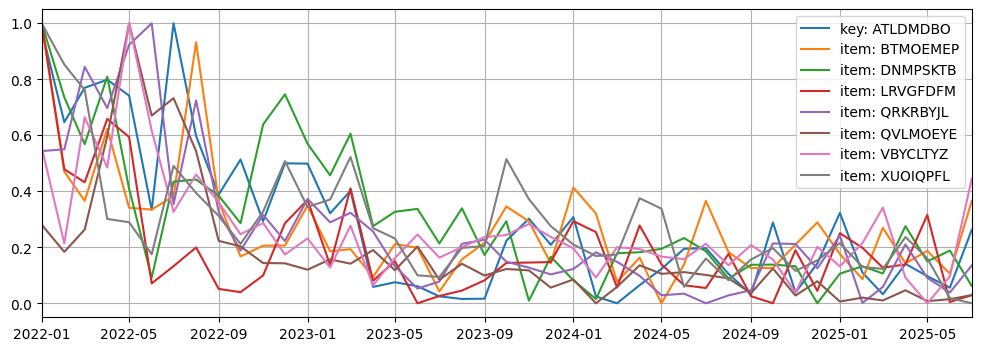

In [90]:
for i, (k, v) in enumerate(dict_hight_corr.items()):
    if k != 'ATLDMDBO': continue
    print(f'index = {i+1}, item, item name: {k} : {v}')

    fig = plt.figure(figsize=(12,4))

    ax = plt.gca()
    ax.plot((pivot.loc[k]-pivot.loc[k].min())/(pivot.loc[k].max()-pivot.loc[k].min()), label=f'key: {k}')

    for j, item in enumerate(v):
        ax.plot((pivot.loc[item]-pivot.loc[item].min())/(pivot.loc[item].max()-pivot.loc[item].min()), label=f'item: {item}')


    ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
    ax.legend()
    ax.grid()
    break

In [91]:
mod_dict_hight_cor = {}

for i, (k, v) in enumerate(dict_hight_corr.items()):
    print(f'index = {i+1}, item, item name: {k} : {v}')

    fig = plt.figure(figsize=(12,4))
    df_hm_plot = pivot.loc[k].to_frame(name=k)
    ax = plt.gca()
    key_name1 = f'{k}'

    lbl_hmap = []
    lbl_hmap.append(key_name1)

    ax.plot((pivot.loc[k] - pivot.loc[k].min()) / (pivot.loc[k].max()- pivot.loc[k].min()), label=key_name1)

    df_hm_plot = pd.concat([df_hm_plot, pivot.loc[k]], axis=0)

    for j, item in enumerate(v):
        key_name2 = f'{item}'
        lbl_hmap.append(key_name2)

        ax.plot((pivot.loc[item]- pivot.loc[item].min())/(pivot.loc[item].max()- pivot.loc[item].min()), label=key_name2, marker='d')

        df_hm_plot[f'{item}'] = pivot.loc[item]


    fig_sns = plt.figure(figsize=(8,6))

    corr_mat= df_hm_plot.corr()
    ax.legend()

    sns.heatmap(corr_mat, annot=True, fmt=".2f", xticklabels=lbl_hmap, yticklabels= lbl_hmap, vmin=-1, vmax=1, center=0)

    tmp_dict = {}
    for m, item in enumerate(dict_hight_corr[k]): # [ v1, v2]
        tmp_dict[item] = round(float(corr_mat.iloc[0, m+1]), 2)

    mod_dict_hight_cor[k] = tmp_dict

ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
ax.grid()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

top2_seq_cat=seq_cnt_low, 9개 아이템, ['ANWUJOKX' 'GIKPEWTY' 'GMBFCMIU' 'KFQSHBNH' 'PLMZALFA' 'QSDCUCLB'
 'RJCAXSGH' 'RUVXNNVA' 'TANNMIMB']
index = 3, 1th item, item name: ANWUJOKX
index = 29, 2th item, item name: GIKPEWTY
index = 31, 3th item, item name: GMBFCMIU
index = 42, 4th item, item name: KFQSHBNH
index = 58, 5th item, item name: PLMZALFA
index = 63, 6th item, item name: QSDCUCLB
index = 67, 7th item, item name: RJCAXSGH
index = 70, 8th item, item name: RUVXNNVA
index = 77, 9th item, item name: TANNMIMB


<Axes: xlabel='item_id', ylabel='item_id'>

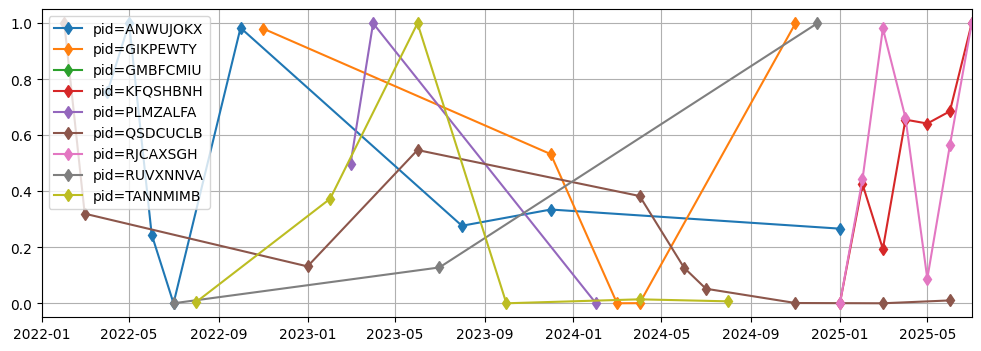

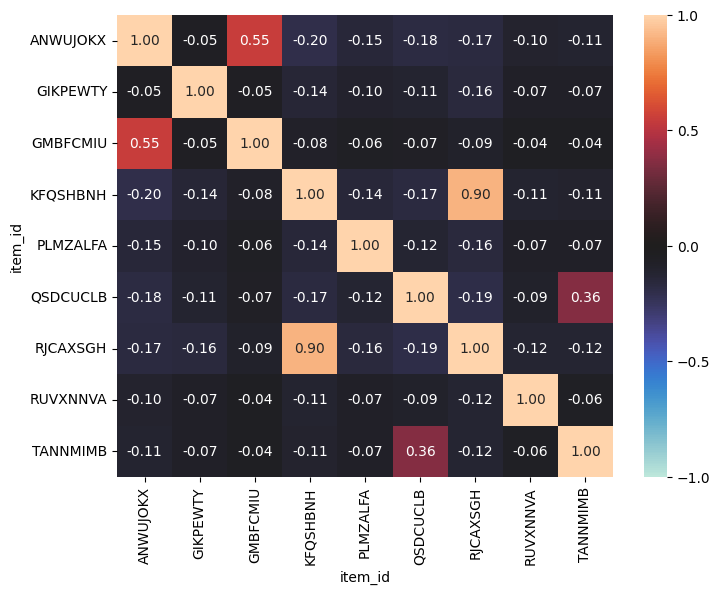

In [93]:
###
### sel_topN_seq_cat = 2 경우
###

sel_topN_seq_cat = 2
print(f'top{sel_topN_seq_cat}_seq_cat={topN_seq_cat[sel_topN_seq_cat-1]}, {len(dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]])}개 아이템, {dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')

        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()

fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f",vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0 )


In [94]:
high_corr = []
for i, row in enumerate(corr_mat[(corr_mat.abs() > 0.5) & corr_mat[(corr_mat.abs() < 0.99)]].iterrows()):
    if row[1].any():
        print(( row[1][row[1].notna()].name, row[1][row[1].notna()].index.to_list()))
        high_corr.append((row[1][row[1].notna()].name, row[1][row[1].notna()].index.to_list()))

('ANWUJOKX', ['GMBFCMIU'])
('GMBFCMIU', ['ANWUJOKX'])
('KFQSHBNH', ['RJCAXSGH'])
('RJCAXSGH', ['KFQSHBNH'])


In [95]:
dict_hight_corr = dict(high_corr)
dict_hight_corr

{'ANWUJOKX': ['GMBFCMIU'],
 'GMBFCMIU': ['ANWUJOKX'],
 'KFQSHBNH': ['RJCAXSGH'],
 'RJCAXSGH': ['KFQSHBNH']}

index = 1, item, item name: ANWUJOKX : ['GMBFCMIU']
index = 2, item, item name: GMBFCMIU : ['ANWUJOKX']
index = 3, item, item name: KFQSHBNH : ['RJCAXSGH']
index = 4, item, item name: RJCAXSGH : ['KFQSHBNH']


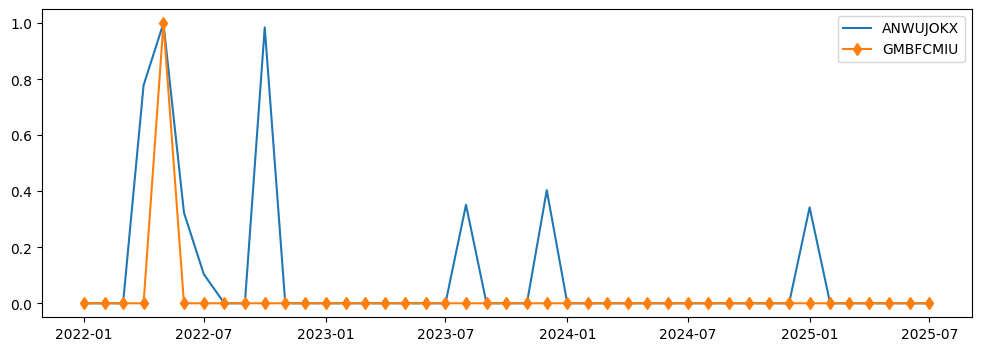

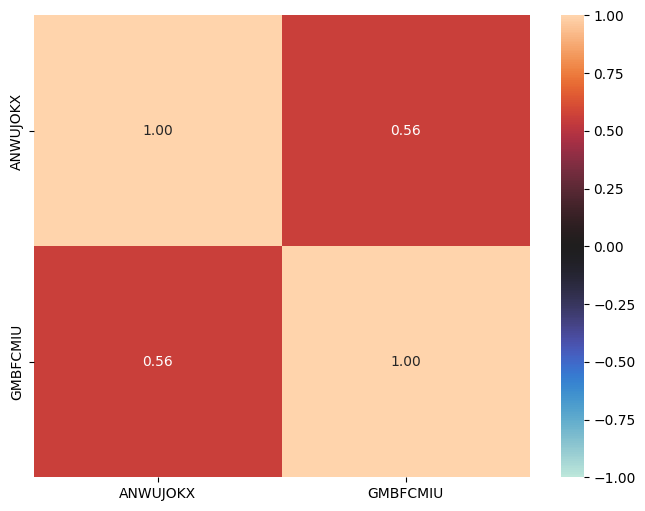

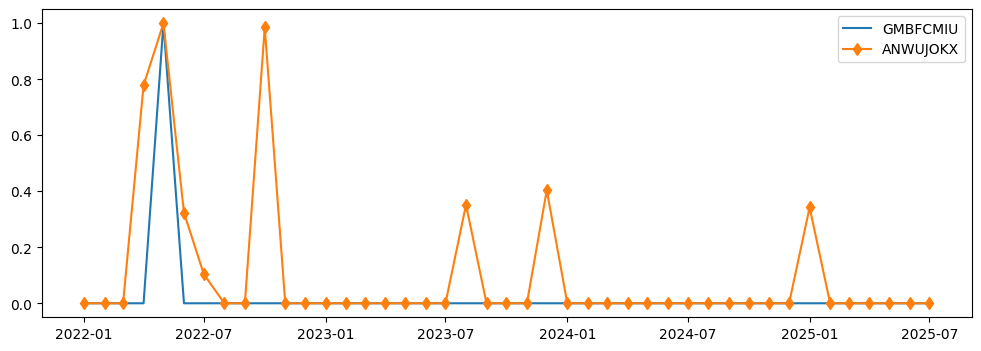

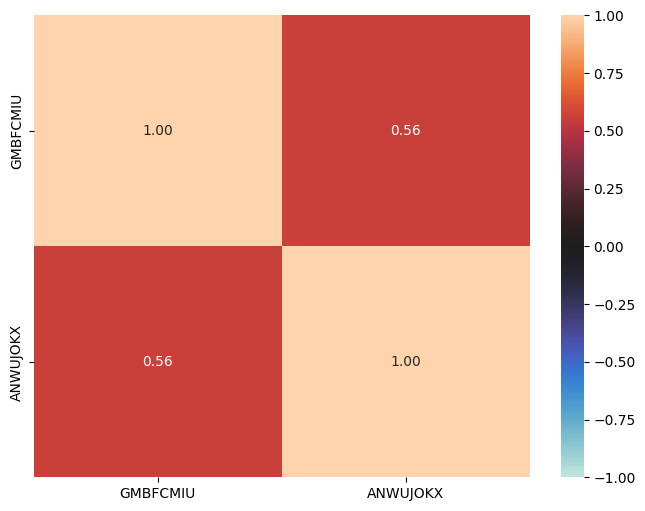

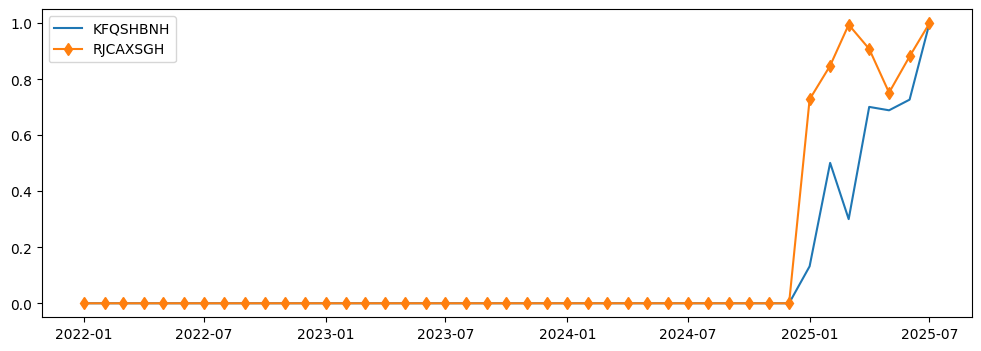

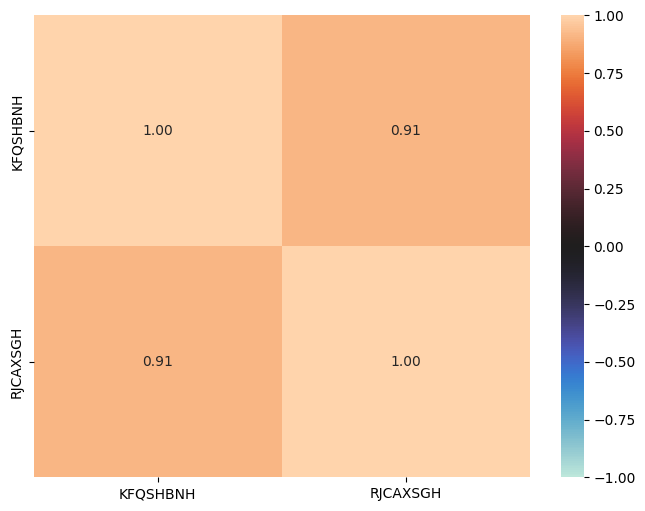

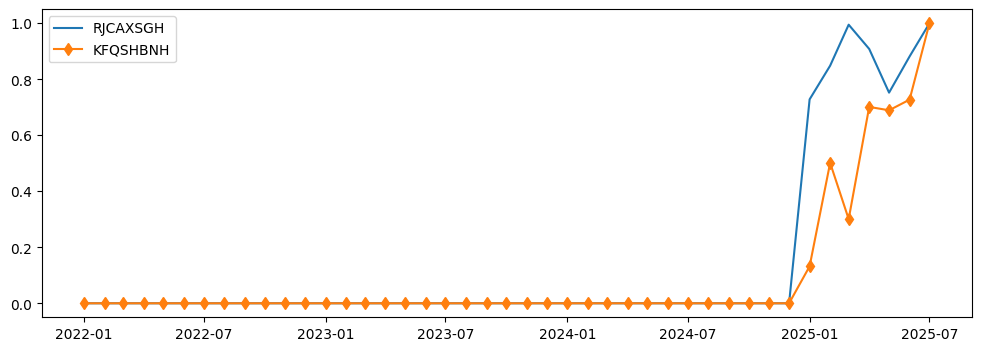

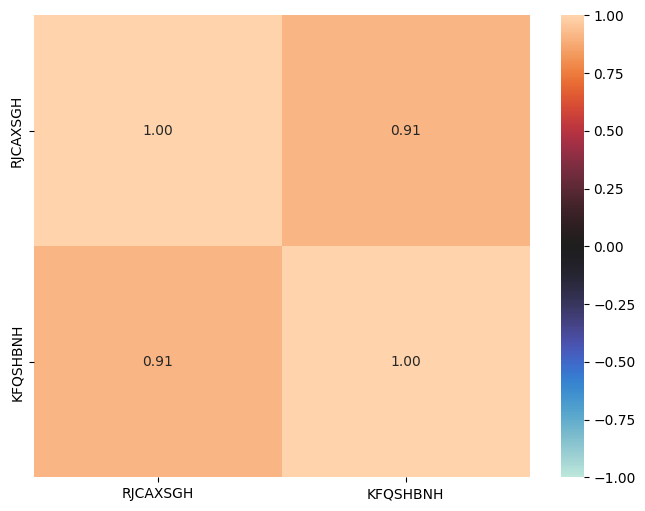

In [96]:
mod_dict_hight_cor = {}

for i, (k, v) in enumerate(dict_hight_corr.items()):
    print(f'index = {i+1}, item, item name: {k} : {v}')

    fig = plt.figure(figsize=(12,4))
    df_hm_plot = pivot.loc[k].to_frame(name=k)
    ax = plt.gca()
    key_name1 = f'{k}'

    lbl_hmap = []
    lbl_hmap.append(key_name1)

    ax.plot((pivot.loc[k] - pivot.loc[k].min()) / (pivot.loc[k].max()- pivot.loc[k].min()), label=key_name1)

    df_hm_plot = pd.concat([df_hm_plot, pivot.loc[k]], axis=0)

    for j, item in enumerate(v):
        key_name2 = f'{item}'
        lbl_hmap.append(key_name2)

        ax.plot((pivot.loc[item]- pivot.loc[item].min())/(pivot.loc[item].max()- pivot.loc[item].min()), label=key_name2, marker='d')

        df_hm_plot[f'{item}'] = pivot.loc[item]


    fig_sns = plt.figure(figsize=(8,6))

    corr_mat= df_hm_plot.corr()
    ax.legend()

    sns.heatmap(corr_mat, annot=True, fmt=".2f", xticklabels=lbl_hmap, yticklabels= lbl_hmap, vmin=-1, vmax=1, center=0)

    tmp_dict = {}
    for m, item in enumerate(dict_hight_corr[k]): # [ v1, v2]
        tmp_dict[item] = round(float(corr_mat.iloc[0, m+1]), 2)


top3_seq_cat=seq_cnt_mid, 10개 아이템, ['AANGBULD' 'BLANHGYY' 'DJBLNPNC' 'FWUCPMMW' 'MIRCVAMV' 'NAQIHUKZ'
 'OGAFEHLU' 'PYZMVUWD' 'TGOELCAG' 'XIIEJNEE']
index = 1, 1th item, item name: AANGBULD
index = 9, 2th item, item name: BLANHGYY
index = 17, 3th item, item name: DJBLNPNC
index = 28, 4th item, item name: FWUCPMMW
index = 51, 5th item, item name: MIRCVAMV
index = 52, 6th item, item name: NAQIHUKZ
index = 54, 7th item, item name: OGAFEHLU
index = 59, 8th item, item name: PYZMVUWD
index = 78, 9th item, item name: TGOELCAG
index = 92, 10th item, item name: XIIEJNEE


<Axes: xlabel='item_id', ylabel='item_id'>

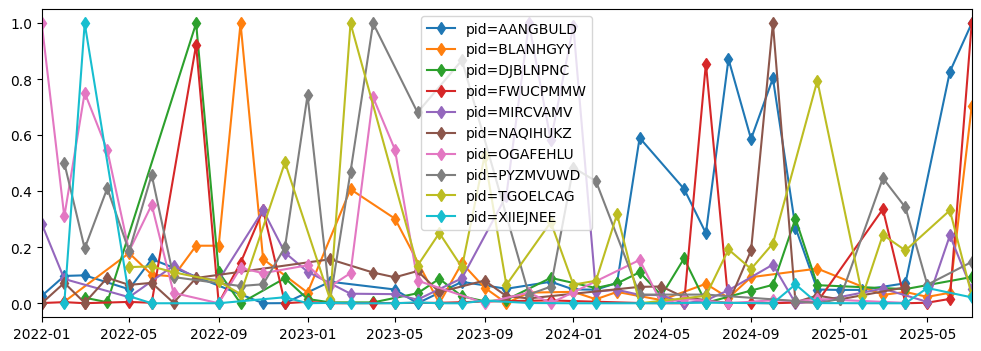

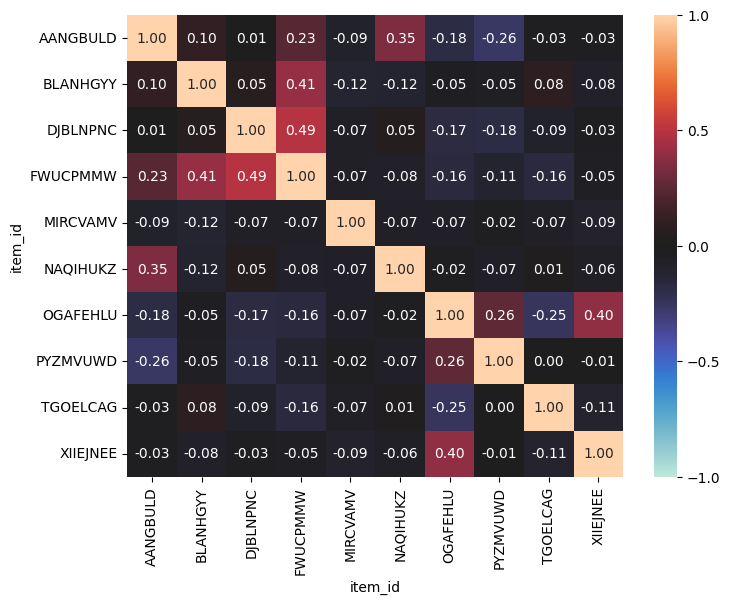

In [97]:
###
### sel_topN_seq_cat = 3 경우
###

sel_topN_seq_cat = 3
print(f'top{sel_topN_seq_cat}_seq_cat={topN_seq_cat[sel_topN_seq_cat-1]}, {len(dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]])}개 아이템, {dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]]}') # top1_hs4 : ['BSRMSVTC' 'DJBLNPNC' 'RCBZUSIM' 'SUOYXCHP' 'WQMVCOEM' 'ZKENOUDA']

df_hm_plot = pd.DataFrame()
j= 0
fig = plt.figure(figsize=(12,4))
for i, group in enumerate(monthly.groupby("item_id")[['item_id','ym', 'value']]):
    if group[0] in dct_seq_cat[topN_seq_cat[sel_topN_seq_cat-1]]:
        j += 1
        print(f'index = {i+1}, {j}th item, item name: {group[0]}')

        df_hm_plot = pd.concat([df_hm_plot, group[1]], axis=0)

        ax = plt.gca()
        ax.plot(group[1]["ym"], (group[1]["value"]- group[1]["value"].min())/(group[1]["value"].max()- group[1]["value"].min()), label=f'pid={group[0]}', marker='d')

        ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
        ax.legend()
        ax.grid()

fig_sns = plt.figure(figsize=(8,6))
corr_mat= pd.pivot_table(df_hm_plot, index='ym', columns='item_id', values='value', fill_value=0).corr()
sns.heatmap(corr_mat, annot=True, fmt=".2f",vmin=-1, vmax=1, cbar_kws={'ticks': [-1, -0.5, 0, 0.5, 1]}, center=0 )


In [98]:
high_corr = []
for i, row in enumerate(corr_mat[(corr_mat.abs() > 0.4) & corr_mat[(corr_mat.abs() < 0.99)]].iterrows()):
    if row[1].any():
        print(( row[1][row[1].notna()].name, row[1][row[1].notna()].index.to_list()))
        high_corr.append((row[1][row[1].notna()].name, row[1][row[1].notna()].index.to_list()))

('BLANHGYY', ['FWUCPMMW'])
('DJBLNPNC', ['FWUCPMMW'])
('FWUCPMMW', ['BLANHGYY', 'DJBLNPNC'])


In [99]:
dict_hight_corr = dict(high_corr)
dict_hight_corr

{'BLANHGYY': ['FWUCPMMW'],
 'DJBLNPNC': ['FWUCPMMW'],
 'FWUCPMMW': ['BLANHGYY', 'DJBLNPNC']}

index = 1, item, item name: BLANHGYY : ['FWUCPMMW']
index = 2, item, item name: DJBLNPNC : ['FWUCPMMW']
index = 3, item, item name: FWUCPMMW : ['BLANHGYY', 'DJBLNPNC']


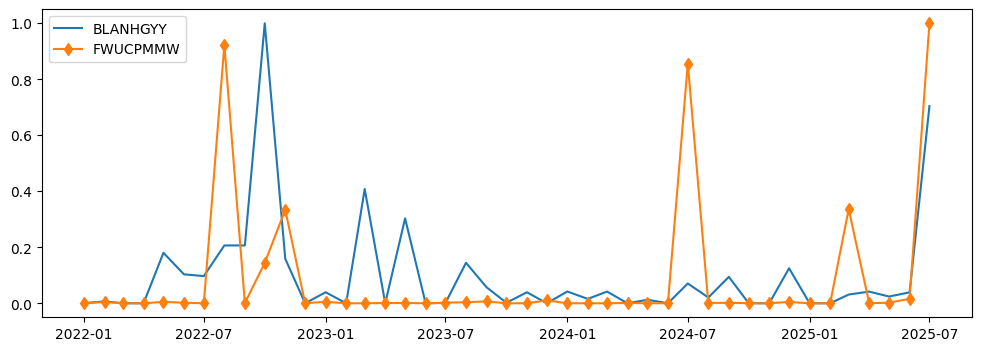

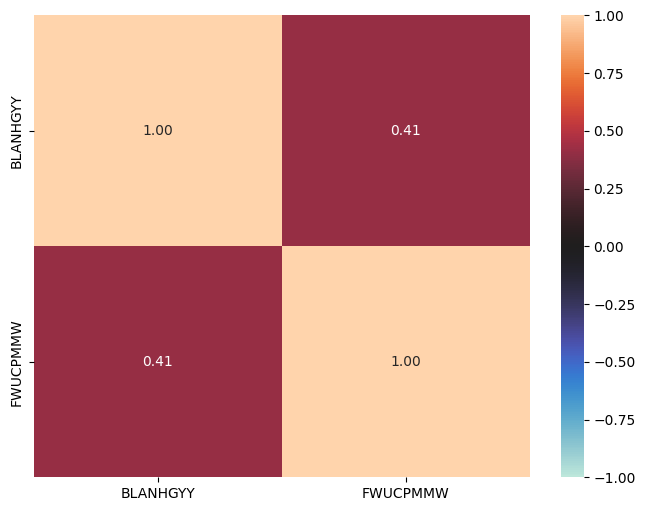

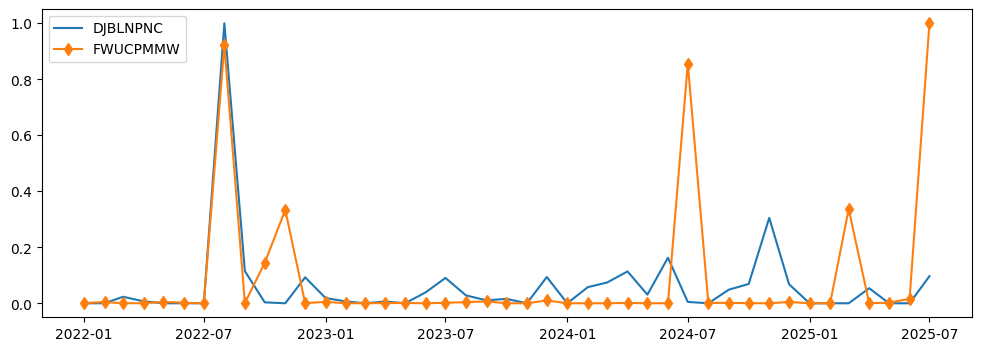

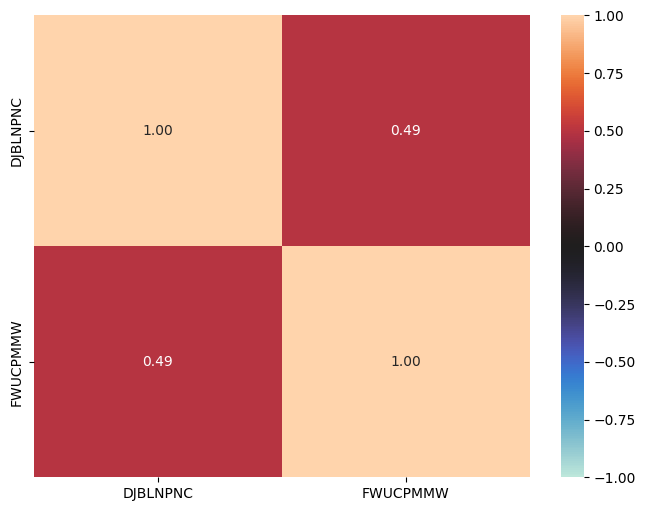

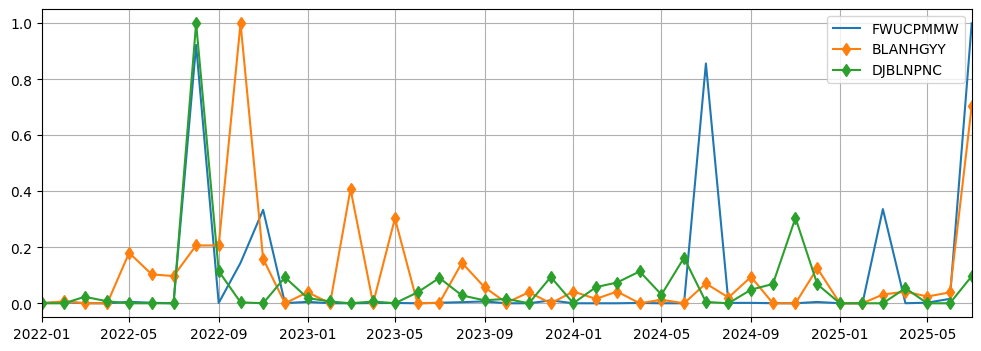

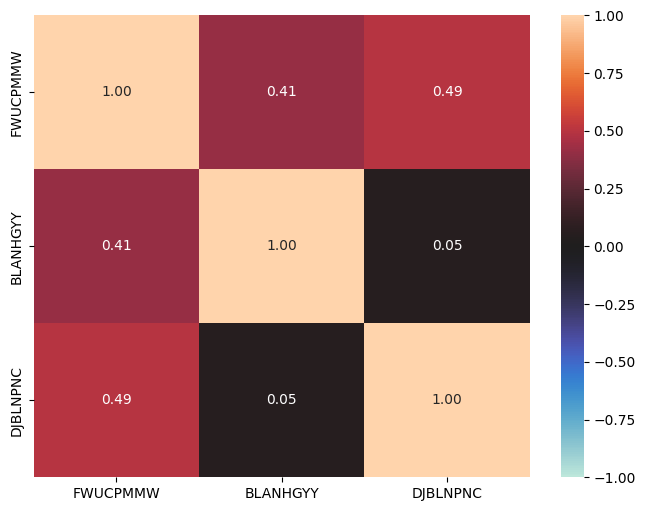

In [100]:
mod_dict_hight_cor = {}

for i, (k, v) in enumerate(dict_hight_corr.items()):
    print(f'index = {i+1}, item, item name: {k} : {v}')

    fig = plt.figure(figsize=(12,4))
    df_hm_plot = pivot.loc[k].to_frame(name=k)
    ax = plt.gca()
    key_name1 = f'{k}'

    lbl_hmap = []
    lbl_hmap.append(key_name1)

    ax.plot((pivot.loc[k] - pivot.loc[k].min()) / (pivot.loc[k].max()- pivot.loc[k].min()), label=key_name1)

    df_hm_plot = pd.concat([df_hm_plot, pivot.loc[k]], axis=0)

    for j, item in enumerate(v):
        key_name2 = f'{item}'
        lbl_hmap.append(key_name2)

        ax.plot((pivot.loc[item]- pivot.loc[item].min())/(pivot.loc[item].max()- pivot.loc[item].min()), label=key_name2, marker='d')

        df_hm_plot[f'{item}'] = pivot.loc[item]


    fig_sns = plt.figure(figsize=(8,6))

    corr_mat= df_hm_plot.corr()
    ax.legend()

    sns.heatmap(corr_mat, annot=True, fmt=".2f", xticklabels=lbl_hmap, yticklabels= lbl_hmap, vmin=-1, vmax=1, center=0)

    tmp_dict = {}
    for m, item in enumerate(dict_hight_corr[k]): # [ v1, v2]
        tmp_dict[item] = round(float(corr_mat.iloc[0, m+1]), 2)

    mod_dict_hight_cor[k] = tmp_dict

ax.set_xlim([monthly['ym'].min(), monthly['ym'].max()])
ax.grid()
plt.show()

### 공행성쌍 데이터

- 각 (A, B) 쌍에 대해 lag = 1 ~ max_lag까지 Pearson 상관계수 계산
- 절댓값이 가장 큰 상관계수와 lag를 선택
- |corr| >= corr_threshold이면 A→B 공행성 있다고 판단

In [103]:
def safe_corr(x, y):
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])

def find_comovement_pairs(pivot, max_lag=6, min_nonzero=12, corr_threshold=0.4):
    items = pivot.index.to_list()
    months = pivot.columns.to_list()
    n_months = len(months)

    results = []

    for i, leader in tqdm(enumerate(items)):
        x = pivot.loc[leader].values.astype(float)
        if np.count_nonzero(x) < min_nonzero:
            continue

        for follower in items:
            if follower == leader:
                continue

            y = pivot.loc[follower].values.astype(float)
            if np.count_nonzero(y) < min_nonzero:
                continue

            best_lag = None
            best_corr = 0.0

            # lag = 1 ~ max_lag 탐색
            for lag in range(1, max_lag + 1):
                if n_months <= lag:
                    continue
                corr = safe_corr(x[:-lag], y[lag:])
                if abs(corr) > abs(best_corr):
                    best_corr = corr
                    best_lag = lag

            # 임계값 이상이면 공행성쌍으로 채택
            if best_lag is not None and abs(best_corr) >= corr_threshold:
                results.append({
                    "leading_item_id": leader,
                    "following_item_id": follower,
                    "best_lag": best_lag,
                    "max_corr": best_corr,
                })

    pairs = pd.DataFrame(results)
    return pairs

pairs = find_comovement_pairs(pivot)
print("탐색된 공행성쌍 수:", len(pairs))
pairs.head()

100it [00:09, 10.11it/s]

탐색된 공행성쌍 수: 1425


,leading_item_id,following_item_id,best_lag,max_corr
0,AANGBULD,APQGTRMF,5,-0.443984
1,AANGBULD,DEWLVASR,6,0.640221
2,AANGBULD,DNMPSKTB,4,-0.410635
3,AANGBULD,EVBVXETX,6,0.436623
4,AANGBULD,FTSVTTSR,3,0.531400


In [104]:
pairs_mod = pairs.copy()
pairs_mod['max_corr_abs'] = pairs_mod['max_corr'].apply(np.abs)
pairs_mod.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1425 entries, 0 to 1424
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   leading_item_id    1425 non-null   object 
 1   following_item_id  1425 non-null   object 
 2   best_lag           1425 non-null   int64  
 3   max_corr           1425 non-null   float64
 4   max_corr_abs       1425 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 55.8+ KB


In [106]:
df_pairs_mod = pairs_mod.groupby('leading_item_id')['following_item_id'] \
    .aggregate(["size"]).sort_values(by='size', ascending=False) # or 'count'
df_pairs_mod

###
### ==> 따라서 100개 아이템중 9개는 공행성쌍이 탐지 되지않았다. ==> 공행성쌍이 탐지 vs. 공행성쌍이 탐지 실패 아이템으로 cat. 가능
###

dct_pair_detection = {'comv_yes':df_pairs_mod.index.to_list() ,
                      'comv_no': set(train_df['item_id']).difference(set(df_pairs_mod.index.to_list()))}
print("공행성이 탐지되지 않은 상품수: ", len(dct_pair_detection['comv_no']))
print("공행성이 탐지되지 않은 상품id: ", dct_pair_detection['comv_no'])
print("공행성 탐지된 상품수: ", len(dct_pair_detection['comv_yes']))
print("공행성이 탐지된 상품id: ", dct_pair_detection['comv_yes'])


공행성이 탐지되지 않은 상품수:  9
공행성이 탐지되지 않은 상품id:  {'RUVXNNVA', 'PLMZALFA', 'TANNMIMB', 'KFQSHBNH', 'GMBFCMIU', 'ANWUJOKX', 'GIKPEWTY', 'RJCAXSGH', 'QSDCUCLB'}
공행성 탐지된 상품수:  91
공행성이 탐지된 상품id:  ['SDWAYPIK', 'DNMPSKTB', 'QRKRBYJL', 'GYHKIVQT', 'OGAFEHLU', 'UGEQLMXM', 'XUOIQPFL', 'WBLJNPZQ', 'QVLMOEYE', 'BTMOEMEP', 'JPBRUTWP', 'APQGTRMF', 'ZGJXVMNI', 'VBYCLTYZ', 'ATLDMDBO', 'ZKENOUDA', 'LRVGFDFM', 'HXYSSRXE', 'BLANHGYY', 'OKMBFVKS', 'OXKURKXR', 'AXULOHBQ', 'XIIEJNEE', 'UXSPKBJR', 'IGDVVKUD', 'EVBVXETX', 'BSRMSVTC', 'FQCLOEXA', 'DEWLVASR', 'NZKBIBNU', 'ELQGMQWE', 'RJGPVEXX', 'DBWLZWNK', 'FDXPMYGF', 'RCBZUSIM', 'LSOIUSXD', 'BEZYMBBT', 'LLHREMKS', 'AANGBULD', 'UIFPPCLR', 'PYZMVUWD', 'SAHWCZNH', 'ROACSLMG', 'LPHPPJUG', 'VUAFAIYJ', 'CCLHWFWF', 'BJALXPFS', 'RAWUKQMJ', 'JBVHSUWY', 'LUENUFGA', 'KJNSOAHR', 'VMAQSTJE', 'DJBLNPNC', 'FWUCPMMW', 'XIFHSOWQ', 'LTOYKIML', 'WPQXWHYO', 'FRHNWLNI', 'FTSVTTSR', 'HCDTGMST', 'KEUWZRKO', 'JSLXRQOK', 'KAGJCHMR', 'AHMDUILJ', 'BUZIIBYG', 'NAQIHUKZ', 'ZCELVYQU', 'MIRCVAMV', 

count : [12. 12. 18. 10.  9.  7.  8.  6.  6.  3.]
bins : [ 2.   5.5  9.  12.5 16.  19.5 23.  26.5 30.  33.5 37. ]
container : <BarContainer object of 10 artists>
2.0 ~ 5.5 : 12개
5.5 ~ 9.0 : 12개
9.0 ~ 12.5 : 18개
12.5 ~ 16.0 : 10개
16.0 ~ 19.5 : 9개
19.5 ~ 23.0 : 7개
23.0 ~ 26.5 : 8개
26.5 ~ 30.0 : 6개
30.0 ~ 33.5 : 6개
33.5 ~ 37.0 : 3개


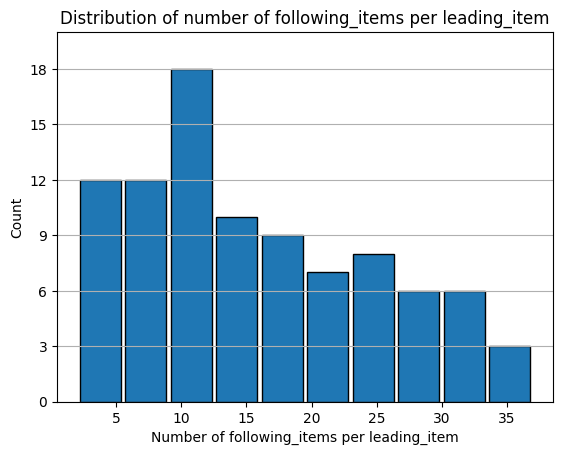

In [108]:
count, bins, container = plt.hist(df_pairs_mod['size'], bins=10, edgecolor='k', rwidth=.9) #
print('count :', count)
print('bins :', bins)
print('container :', container)


for i in range(len(bins)-1):
    print(f'{bins[i]} ~ {bins[i+1]} : {int(count[i])}개')

plt.xlabel('Number of following_items per leading_item')
plt.ylabel('Count')
plt.ylim([0, 20])
plt.yticks([0, 3, 6, 9, 12, 15, 18])
plt.grid(axis='y')

plt.title("Distribution of number of following_items per leading_item")
plt.show()

count : [214. 248. 229. 232. 230. 272.]
bins : [1.         1.83333333 2.66666667 3.5        4.33333333 5.16666667
 6.        ]
container : <BarContainer object of 6 artists>
1.0 ~ 1.8333333333333335 : 214개
1.8333333333333335 ~ 2.666666666666667 : 248개
2.666666666666667 ~ 3.5 : 229개
3.5 ~ 4.333333333333334 : 232개
4.333333333333334 ~ 5.166666666666667 : 230개
5.166666666666667 ~ 6.0 : 272개


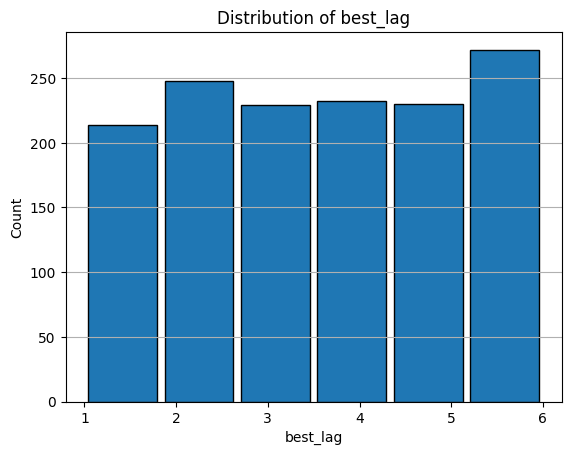

In [109]:
count, bins, container = plt.hist(pairs_mod['best_lag'], bins=6, edgecolor='k', rwidth=.9)
print('count :', count)
print('bins :', bins)
print('container :', container)


for i in range(len(bins)-1):
    print(f'{bins[i]} ~ {bins[i+1]} : {int(count[i])}개')

plt.xlabel('best_lag')
plt.ylabel('Count')
plt.grid(axis='y')

plt.title("Distribution of best_lag")
plt.show()

count : [  6.  41. 116. 169.   0.   0.   0.   0.   0.   0.   0.   0.   0. 299.
 412. 204. 107.  52.  13.   6.]
bins : [-0.70833733 -0.62648981 -0.54464228 -0.46279476 -0.38094723 -0.29909971
 -0.21725218 -0.13540466 -0.05355713  0.02829039  0.11013792  0.19198544
  0.27383296  0.35568049  0.43752801  0.51937554  0.60122306  0.68307059
  0.76491811  0.84676564  0.92861316]
container : <BarContainer object of 20 artists>


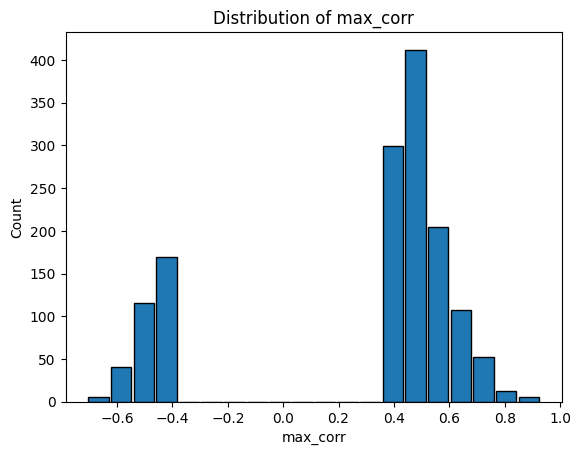

In [110]:
count, bins, container = plt.hist(pairs_mod['max_corr'], bins=20, edgecolor='k', rwidth=.9)
print('count :', count)
print('bins :', bins)
print('container :', container)


plt.xlabel('max_corr')
plt.ylabel('Count')
plt.title("Distribution of max_corr")
plt.show()

In [111]:
pivot

ym,2022-01-01,2022-02-01,2022-03-01,2022-04-01,2022-05-01,2022-06-01,2022-07-01,2022-08-01,2022-09-01,2022-10-01,...,2024-10-01,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01
item_id,,,,,,,,,,,,,,,,,,,,,
AANGBULD,14276.0,52347.0,53549.0,0.0,26997.0,84489.0,0.0,0.0,0.0,0.0,...,428725.0,144248.0,26507.0,25691.0,25805.0,0.0,38441.0,0.0,441275.0,533478.0
AHMDUILJ,242705.0,120847.0,197317.0,126142.0,71730.0,149138.0,186617.0,169995.0,140547.0,89292.0,...,123085.0,143451.0,78649.0,125098.0,80404.0,157401.0,115509.0,127473.0,89479.0,101317.0
ANWUJOKX,0.0,0.0,0.0,63580.0,81670.0,26424.0,8470.0,0.0,0.0,80475.0,...,0.0,0.0,0.0,27980.0,0.0,0.0,0.0,0.0,0.0,0.0
APQGTRMF,383999.0,512813.0,217064.0,470398.0,539873.0,582317.0,759980.0,216019.0,537693.0,205326.0,...,683581.0,2147.0,0.0,25013.0,77.0,20741.0,2403.0,3543.0,32430.0,40608.0
ATLDMDBO,143097177.0,103568323.0,118403737.0,121873741.0,115024617.0,65716075.0,146216818.0,97552978.0,72341427.0,87454167.0,...,60276050.0,30160198.0,42613728.0,64451013.0,38667429.0,29354408.0,42450439.0,37136720.0,32181798.0,57090235.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YSYHGLQK,0.0,543.0,766.0,1108.0,859.0,1426.0,2413.0,638.0,0.0,1199.0,...,188.0,541.0,696.0,8710.0,3175.0,2624.0,0.0,182.0,2128.0,10651.0
ZCELVYQU,373859.0,59900.0,31158.0,594407.0,648232.0,496737.0,210179.0,0.0,70748.0,15512.0,...,0.0,609803.0,23712.0,654630.0,4496.0,1177300.0,1187539.0,26434.0,115631.0,270262.0
ZGJXVMNI,1154724.0,1337622.0,1662893.0,1561647.0,1603223.0,1641942.0,1815161.0,1546959.0,1536799.0,1496906.0,...,3168505.0,3059865.0,1579976.0,1413293.0,3038078.0,2915914.0,3565526.0,3020051.0,2412781.0,2458481.0


In [117]:
pairs.to_csv('pairs.csv', index=False)

In [118]:
pd.read_csv('./pairs.csv')

,leading_item_id,following_item_id,best_lag,max_corr
0,AANGBULD,APQGTRMF,5,-0.443984
1,AANGBULD,DEWLVASR,6,0.640221
2,AANGBULD,DNMPSKTB,4,-0.410635
3,AANGBULD,EVBVXETX,6,0.436623
4,AANGBULD,FTSVTTSR,3,0.531400
...,...,...,...,...
1420,ZXERAXWP,DBWLZWNK,6,-0.470150
1421,ZXERAXWP,FITUEHWN,4,0.406369
1422,ZXERAXWP,MIRCVAMV,3,-0.435495
1423,ZXERAXWP,UIFPPCLR,1,-0.526205
